## **1. Establezca una conexión con la api de sentinel 2, puede usar para eso el módulo openeo.**

In [3]:
import openeo
conn = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## **2 y 3.**

Descarga los .tif de cada uno de los lagos usando para eso las coordenadas o el geojson provisto.

Selecciona un período de observación: mínimo 6 meses. Tenga en cuenta que serán útiles imágenes con menos nubosidad.

In [ ]:
COLLECTION = "SENTINEL2_L1C"                 
TEMPORAL_EXTENT = ["2025-01-01", "2025-08-14"]
MAX_CLOUD = 20

BANDS = ["B02", "B03", "B04", "B05", "B07", "B8A", "B08", "B11", "B12"]

# BBoxes (EPSG:4326)
lago_atitlan = {"west": -91.326256, "east": -91.07151, "south": 14.5948,   "north": 14.750979}
lago_amatitlan = {"west": -90.638065, "east": -90.512924, "south": 14.412347, "north": 14.493799}

def to_extent(box):
    return {"west": box["west"], "south": box["south"], "east": box["east"], "north": box["north"], "crs": "EPSG:4326"}

def descargar_lago(nombre, box, carpeta):
    print(f"\n🔎 {nombre}: S2 L1C {TEMPORAL_EXTENT[0]} → {TEMPORAL_EXTENT[1]} con ≤{MAX_CLOUD}% nubes, remuestreado a 10 m (EPSG:32616)…")

    cube = conn.load_collection(
        collection_id=COLLECTION,
        spatial_extent=to_extent(box),
        temporal_extent=TEMPORAL_EXTENT,
        bands=BANDS,
        max_cloud_cover=MAX_CLOUD
    )

    # remuestreo a 10 m y proyección común (UTM 16N ~ Guatemala)
    cube = cube.resample_spatial(resolution=10, projection="EPSG:32616", method="near")

    # GeoTIFF multibanda por fecha (time-slices)
    result = cube.save_result(format="GTIFF")
    job = conn.create_job(result, title=f"{nombre} S2 L1C ≤{MAX_CLOUD}% (ene-ago 2025, 10m)")
    job.start_and_wait().get_results().download_files(target=carpeta)

    print(f"✅ {nombre}: archivos guardados en './{carpeta}'")


descargar_lago("Lago Atitlán",   lago_atitlan,   "descargas_atitlan_fechas")
descargar_lago("Lago Amatitlán", lago_amatitlan, "descargas_amatitlan")

## **4. Aplica el script de detección de cianobacteria de Sentinel Hub (por ejemplo, Cyano Detection Script) para cada imagen.**
    # 4.1. Puede calcularlo en copernicus browser y descargar los resultados o puede calcularlo usando para eso las bandas que incluyó la descarga de cada una de las imágenes.

In [33]:
import os, glob, re
import numpy as np
import rasterio
from tqdm import tqdm
import pandas as pd
import scipy.ndimage as ndi  

IN_DIRS = [
    ("Lago Atitlán", "descargas_atitlan_fechas"),
    ("Lago Amatitlán", "descargas_amatitlan"),
]

OUT_BASE = "ciano_outputs"  # rasters procesados espejo a la estructura de entrada
TS_OUT   = "timeseries"     # CSV por lago
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(TS_OUT, exist_ok=True)

def safe_div(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.true_divide(a, b)
        out[~np.isfinite(out)] = 0.0
    return out

def open_bands(path):
    """
    Abre tif multibanda con B02,B03,B04,B05,B07,B8A,B08,B11,B12 (en ese orden).
    Normaliza a [0,1] si vienen en 0..10000 (reflectancia escalada).
    """
    names = ["B02","B03","B04","B05","B07","B8A","B08","B11","B12"]
    with rasterio.open(path) as src:
        if src.count < 9:
            raise ValueError(f"{path} necesita 9 bandas (tiene {src.count})")
        arr = {}
        for i, n in enumerate(names, 1):
            b = src.read(i).astype(np.float32)
            if np.nanpercentile(b, 99) > 1.5:  
                b = b / 10000.0
            b = np.clip(b, 0.0, 1.0)
            arr[n] = b
        profile = src.profile
    return arr, profile

def cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                      thr_vis=0.20, thr_swir=0.10,
                      thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                      dilate_px=1):
    """
    True = ENMASCARAR (nube/sombra).
      - Nube: muy brillante en visible (B02-04) y elevada en SWIR (B11/B12).
      - Sombra: muy oscura en NIR (B08) y SWIR.
    Todas las bandas deben estar en reflectancia [0..1].
    """
    bright_vis  = (B02 > thr_vis) & (B03 > thr_vis) & (B04 > thr_vis)
    bright_swir = (B11 > thr_swir) | (B12 > thr_swir)
    cloud = bright_vis & bright_swir

    shadow = (B08 < thr_shadow_nir) & ((B11 < thr_shadow_swir) | (B12 < thr_shadow_swir))

    mask = cloud | shadow
    if dilate_px and np.any(mask):
        mask = ndi.binary_dilation(mask, iterations=dilate_px)
    return mask

def wbi(B04,B03,B02,B08,B11,B12, MNDWI_threshold=0.42, NDWI_threshold=0.4, filter_UABS=True):
    ndvi = safe_div((B08 - B04), (B08 + B04))
    mndwi = safe_div((B03 - B11), (B03 + B11))
    ndwi = safe_div((B03 - B08), (B03 + B08))
    ndwi_leaves = safe_div((B08 - B11), (B08 + B11))
    aweish = B02 + 2.5*B03 - 1.5*(B08 + B11) - 0.25*B12
    aweinsh = 4*(B03 - B11) - (0.25*B08 + 2.75*B11)
    dbsi = safe_div((B11 - B03), (B11 + B03)) - ndvi

    ws = np.zeros(B04.shape, dtype=np.uint8)
    cond_water = (
        (mndwi > MNDWI_threshold) |
        (ndwi  > NDWI_threshold)  |
        (aweinsh > 0.1879)        |
        (aweish  > 0.1112)        |
        (ndvi    < -0.2)          |
        (ndwi_leaves > 1)
    )
    ws[cond_water] = 1
    if filter_UABS:
        cond_urban_bare = (aweinsh <= -0.03) | (dbsi > 0)
        ws[cond_urban_bare] = 0
    return ws

def FAI(B04, B07, B8A):
    return (B07 - B04) - (B8A - B04) * ((783.0 - 665.0)/(865.0 - 665.0))

def NDCI(B04, B05):
    return safe_div((B05 - B04), (B05 + B04))

def chl_from_ndci(ndci):
    return 826.57*(ndci**3) - 176.43*(ndci**2) + 19.0*ndci + 4.071


PALETTE = [
    (0.5,   (0,  0,255)),
    (1,     (0,  0,255)),
    (2.5,   (0, 59,255)),
    (3.5,   (0, 98,255)),
    (5,     (15,113,141)),
    (7,     (14,141,120)),
    (8,     (13,141,103)),
    (10,    (30,226, 28)),
    (14,    (42,226, 28)),
    (18,    (68,226, 28)),
    (20,    (68,226, 28)),
    (24,    (134,247, 0)),
    (28,    (140,247, 0)),
    (30,    (205,237, 0)),
    (38,    (208,240, 0)),
    (45,    (208,240, 0)),
    (50,    (251,210, 3)),
    (75,    (248,207, 2)),
    (90,    (134,247, 0)),
    (100,   (245,164, 9)),
    (150,   (240,159, 8)),
    (250,   (237,157, 7)),
    (300,   (239,118,15)),
    (350,   (239,101,15)),
    (450,   (239,100,14)),
    (500,   (233, 72,21)),
]
FAI_COLOR = (233, 72, 21)
FALLBACK  = (233, 72, 21)

def render_rgb(water, FAIv, chl, B04,B03,B02):
    H, W = chl.shape
    rgb = np.zeros((3, H, W), dtype=np.uint8)
    # tierra -> true color (3*B04, 3*B03, 3*B02)
    land = (water == 0)
    tc = np.stack([3*B04, 3*B03, 3*B02], axis=0)
    tc255 = np.clip(tc*255.0, 0, 255).astype(np.uint8)
    rgb[:, land] = tc255[:, land]
    # agua
    agua = (water == 1)
    # FAI primero
    fai_mask = agua & (FAIv > 0.08)
    if np.any(fai_mask):
        rgb[:, fai_mask] = np.array(FAI_COLOR, dtype=np.uint8)[:, None]
    restante = agua & (~fai_mask)
    if np.any(restante):
        assigned = np.zeros_like(restante, dtype=bool)
        for thr, col in PALETTE:
            m = restante & (~assigned) & (chl < thr)
            if np.any(m):
                rgb[:, m] = np.array(col, dtype=np.uint8)[:, None]
                assigned[m] = True
        m_fb = restante & (~assigned)
        if np.any(m_fb):
            rgb[:, m_fb] = np.array(FALLBACK, dtype=np.uint8)[:, None]
    return rgb

def process_one(in_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    bands, profile = open_bands(in_path)

    B02 = bands["B02"]; B03 = bands["B03"]; B04 = bands["B04"]; B05 = bands["B05"]
    B07 = bands["B07"]; B8A = bands["B8A"]; B08 = bands["B08"]; B11 = bands["B11"]; B12 = bands["B12"]

    # 0) máscara de nubes/sombras solo con L1C
    m_cloud = cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                                thr_vis=0.20, thr_swir=0.10,
                                thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                                dilate_px=1)

    # 1) máscara de agua (WBI)
    water = wbi(B04,B03,B02,B08,B11,B12).astype(bool)

    # 2) índices espectrales
    FAIv  = FAI(B04,B07,B8A)
    ndci  = NDCI(B04,B05)
    chl   = chl_from_ndci(ndci).astype(np.float32)

    # 3) máscara final: fuera de agua O nubes/sombras -> NaN
    m_nodata = (~water) | m_cloud
    chl_masked = chl.copy()
    chl_masked[m_nodata] = np.nan

    # 4) clip físico para estabilidad
    chl_masked = np.clip(chl_masked, 0.0, 500.0)

    # 5) render temático (usa water y chl_masked)
    rgb = render_rgb(water.astype(np.uint8), FAIv, chl_masked, B04,B03,B02)

    base = os.path.splitext(os.path.basename(in_path))[0]
    rgb_path = os.path.join(out_dir, f"{base}_cyano_rgb.tif")
    chl_path = os.path.join(out_dir, f"{base}_chl.tif")

    # RGB
    rgb_prof = profile.copy()
    rgb_prof.update({"count": 3, "dtype": "uint8", "compress": "lzw", "nodata": None})
    with rasterio.open(rgb_path, "w", **rgb_prof) as dst:
        dst.write(rgb[0], 1); dst.write(rgb[1], 2); dst.write(rgb[2], 3)

    # Chl-a (float32) con NaN fuera de agua/nubes/sombras
    chl_prof = profile.copy()
    chl_prof.update({"count": 1, "dtype": "float32", "compress": "lzw", "nodata": np.nan})
    with rasterio.open(chl_path, "w", **chl_prof) as dst:
        dst.write(chl_masked, 1)

    return rgb_path, chl_path

def walk_and_process(in_root, out_root):
    tifs = sorted(glob.glob(os.path.join(in_root, "**", "*.tif"), recursive=True))
    if not tifs:
        print(f"⚠️ No hay .tif en {in_root}")
        return []
    out_chl_files = []
    print(f"Procesando {len(tifs)} archivos de {in_root} …")
    for tif in tqdm(tifs):
        rel = os.path.relpath(os.path.dirname(tif), in_root)
        out_dir = os.path.join(out_root, rel)
        try:
            _, chl_path = process_one(tif, out_dir)
            out_chl_files.append(chl_path)
        except Exception as e:
            print(f"❌ Error en {tif}: {e}")
    return out_chl_files

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date_from_path(p):
    m = DATE_RE.search(p)
    return m.group(1) if m else None

def summarize_chl(chl_tif):
    with rasterio.open(chl_tif) as src:
        a = src.read(1).astype(np.float32)
    valid = np.isfinite(a)
    if not np.any(valid):
        return dict(mean=np.nan, median=np.nan, p90=np.nan, std=np.nan, water_px=0)
    vals = a[valid]
    return dict(
        mean   = float(np.nanmean(vals)),
        median = float(np.nanmedian(vals)),
        p90    = float(np.nanpercentile(vals, 90)),
        std    = float(np.nanstd(vals)),
        water_px = int(valid.sum())
    )

def build_timeseries(lake_name, out_root, csv_path):
    chl_files = sorted(glob.glob(os.path.join(out_root, "**", "*_chl.tif"), recursive=True))
    rows = []
    for f in chl_files:
        d = extract_date_from_path(f)
        if d is None:
            continue
        stats = summarize_chl(f)
        rows.append({"date": d, **stats})
    if not rows:
        print(f"⚠️ {lake_name}: no se pudieron construir series (sin fechas detectadas).")
        return
    df = pd.DataFrame(rows).sort_values("date")
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["timestamp_s"]  = (df.index.view("int64") // 10**9).astype("int64")        
    df["date_ordinal"] = df.index.map(pd.Timestamp.toordinal).astype("int64")      
    df["doy"]          = df.index.dayofyear.astype("int64")
    df["year"]         = df.index.year.astype("int64")
    df["month"]        = df.index.month.astype("int64")
    df["day"]          = df.index.day.astype("int64")
    df.to_csv(csv_path, index=True)
    print(f"🧾 Serie temporal guardada: {csv_path}")
    return df


for lake_name, in_dir in IN_DIRS:
    print(f"\n=== {lake_name} ===")
    out_dir = os.path.join(OUT_BASE, os.path.basename(in_dir))
    chl_files = walk_and_process(in_dir, out_dir)
    csv_path = os.path.join(TS_OUT, f"{os.path.basename(in_dir)}_chl_timeseries.csv")
    build_timeseries(lake_name, out_dir, csv_path)

print("\n✅ Listo. Rasters en:", OUT_BASE, " | Series en:", TS_OUT)


=== Lago Atitlán ===
Procesando 23 archivos de descargas_atitlan_fechas …


100%|██████████| 23/23 [00:19<00:00,  1.21it/s]


🧾 Serie temporal guardada: timeseries/descargas_atitlan_fechas_chl_timeseries.csv

=== Lago Amatitlán ===
Procesando 30 archivos de descargas_amatitlan …


100%|██████████| 30/30 [00:06<00:00,  4.73it/s]


🧾 Serie temporal guardada: timeseries/descargas_amatitlan_chl_timeseries.csv

✅ Listo. Rasters en: ciano_outputs  | Series en: timeseries


*Suavizar y mejorar las vistas tanto de ati como amati*

✅ Guardado: chl_soft_out_ati/resumen_Atitlán_chl_soft.csv
Escala global CHL_soft: vmin=2.3, vmax=9.0


/var/folders/fd/7pj5mc8x0pn8jx56z039h30m0000gn/T/ipykernel_4258/2294392066.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


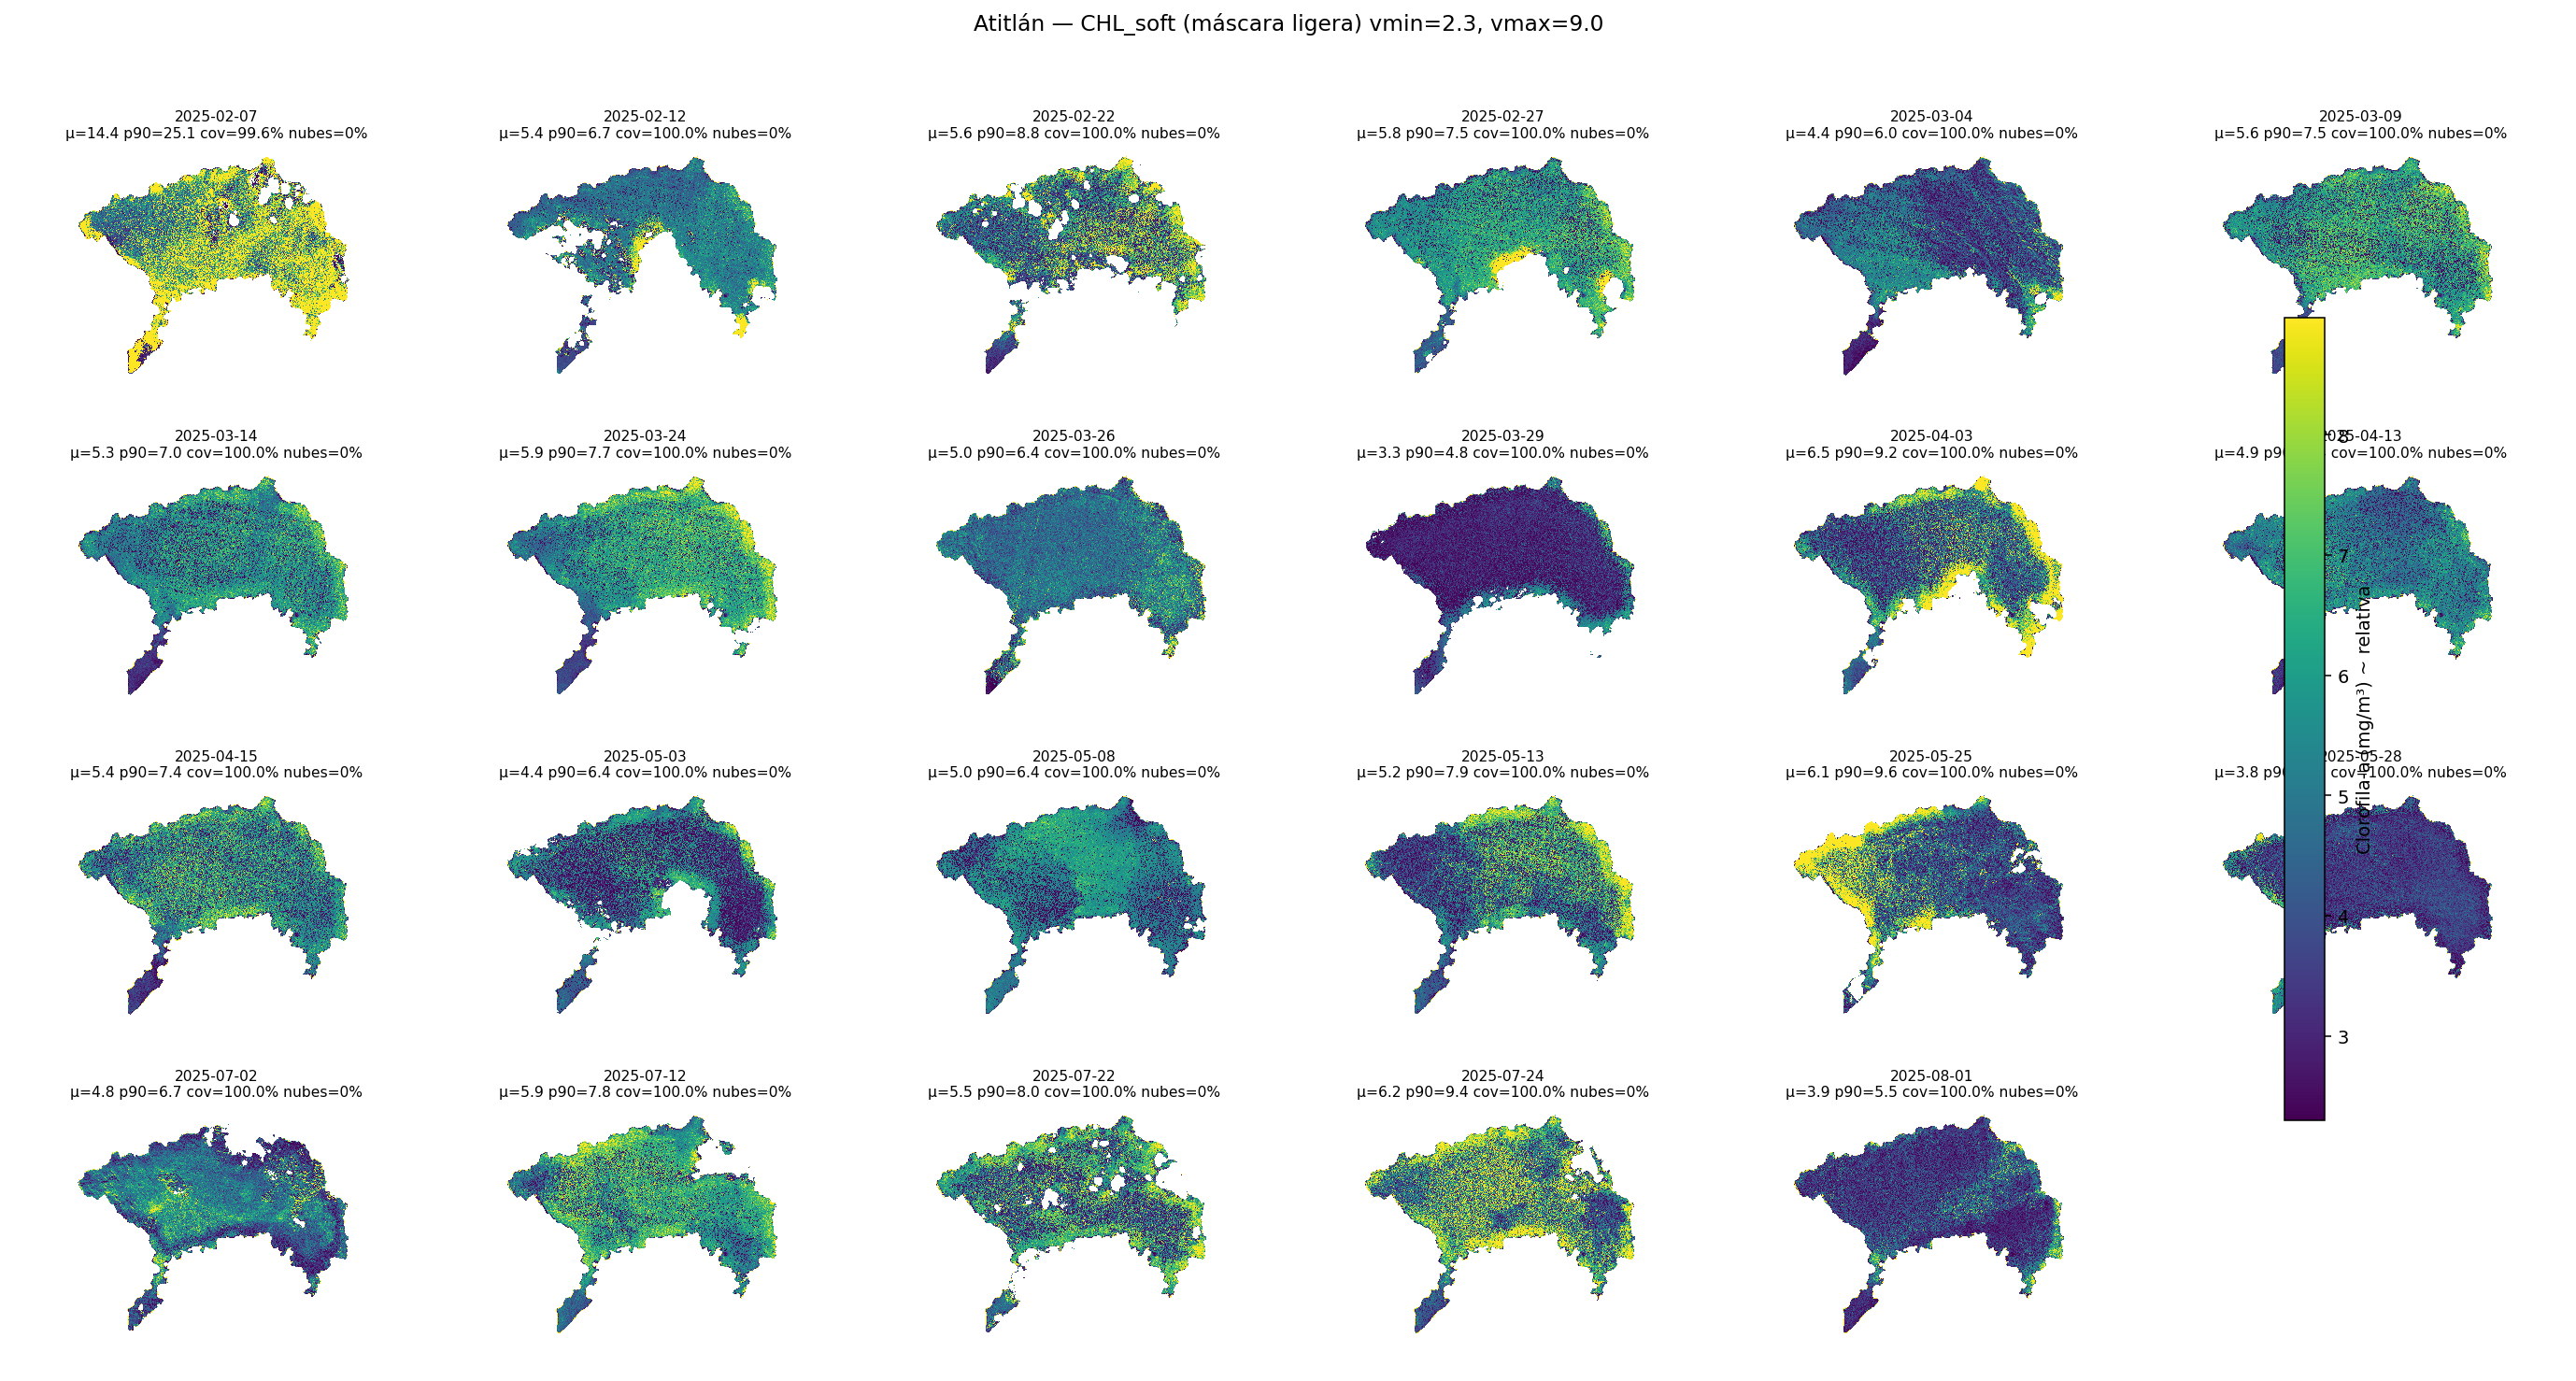

In [34]:
import os, glob, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling, transform_geom
from rasterio import features
import matplotlib.pyplot as plt

LAKE_NAME = "Atitlán"
L2A_DIR   = "descargas_atitlan_fechas"          
USE_POLYGON = os.path.exists("lago_atitlan.geojson")
LAKE_POLYGON_GEOJSON = "lago_atitlan.geojson"   
OUT_DIR   = "chl_soft_out_ati"
NCOLS     = 6

SCL_CLOUDS = {3,8,9,10,11}        # sombras, nubes med/altas, cirrus, nieve/hielo
ERODE_WATER_PIXELS = 0            # 0 = sin erosión (más laxo); sube a 1–2 si ves orillas sucias

V_CLAMP = (0, 200)                
P_LOW, P_HIGH = 5, 95

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

def list_openEO(L2A_DIR):
    files = sorted(glob.glob(os.path.join(L2A_DIR, "openEO_*Z.tif")))
    items = []
    for p in files:
        m = DATE_RE.search(os.path.basename(p))
        if m:
            items.append((m.group(1), p))
    return items

def rasterize_polygon_on(transform, shape, dst_crs, geojson_path):
    with open(geojson_path, "r", encoding="utf-8") as f:
        gj = json.load(f)
    if gj.get("type") == "FeatureCollection":
        geoms = [g["geometry"] for g in gj["features"]]
    elif gj.get("type") == "Feature":
        geoms = [gj["geometry"]]
    else:
        geoms = [gj]
    geoms = [(transform_geom("EPSG:4326", dst_crs.to_string(), g), 1) for g in geoms]
    mask = features.rasterize(geoms, out_shape=shape, transform=transform,
                              fill=0, all_touched=True, dtype="uint8").astype(bool)
    return mask

def to_match_band(src_path, band_index, dst_tr, dst_crs, W, H, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        out = np.full((H,W), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, band_index),
            destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=dst_tr,    dst_crs=dst_crs,
            resampling=resampling,
            src_nodata=src.nodata, dst_nodata=np.nan
        )
    return out

def soft_masks_from_SCL(scl, lake_mask):
    # rellena NaN de SCL con -1 para poder castear sin warnings
    scl = np.where(np.isfinite(scl), scl, -1).astype(np.int16)
    cloud_mask = np.isin(scl, list(SCL_CLOUDS))
    if USE_POLYGON:
        water_mask = lake_mask.copy()
    else:
        # SIN polígono: usa agua SCL==6 
        water_mask = (scl == 6)
    if ERODE_WATER_PIXELS > 0:
        try:
            from scipy.ndimage import binary_erosion
            water_mask = binary_erosion(water_mask, iterations=ERODE_WATER_PIXELS,
                                        structure=np.ones((3,3), dtype=bool))
        except Exception:
            pass
    valid = water_mask & (~cloud_mask)
    return valid, water_mask, cloud_mask

def compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05):
    # Índices "suaves"
    tiny = 1e-6
    with np.errstate(divide='ignore', invalid='ignore'):
        ndci = (rrs_b05 - rrs_b04) / (rrs_b05 + rrs_b04 + tiny)
        oc3  = np.log10((rrs_b02 + tiny) / (rrs_b03 + tiny))
    # Combinación pragmática (ajusta coeficientes si quieres)
    chl_low  = 10 ** (0.4 + 3.0 * oc3)            # cloros bajas/medias
    chl_high = 40.0 * ndci + 2.0                  # cloros altas (lineal en NDCI)
    chl_soft = np.where(ndci > 0, chl_high, chl_low)
    chl_soft = np.clip(chl_soft, V_CLAMP[0], V_CLAMP[1])
    chl_soft[~np.isfinite(chl_soft)] = np.nan
    return ndci, oc3, chl_soft

items = list_openEO(L2A_DIR)
if not items:
    raise SystemExit(f"No encontré multibandas openEO_*Z.tif en {L2A_DIR}")

rows, stacks = [], []
for date_iso, mb in items:
    with rasterio.open(mb) as src:
        H,W = src.height, src.width
        dst_tr, dst_crs = src.transform, src.crs
        # Sentinel-2 L2A (openEO): orden típico de bandas
        b02 = src.read(1).astype(np.float32)   # 490 nm
        b03 = src.read(2).astype(np.float32)   # 560 nm
        b04 = src.read(3).astype(np.float32)   # 665 nm
        b05 = src.read(4).astype(np.float32)   # 705 nm
        scl = src.read(10).astype(np.float32)  # SCL
        # escala a reflectancia 0..1
        rrs_b02 = b02 / 10000.0
        rrs_b03 = b03 / 10000.0
        rrs_b04 = b04 / 10000.0
        rrs_b05 = b05 / 10000.0

    # máscara lago
    if USE_POLYGON:
        lake_mask = rasterize_polygon_on(dst_tr, (H,W), dst_crs, LAKE_POLYGON_GEOJSON)
    else:
        lake_mask = np.ones((H,W), dtype=bool)

    # máscara ligera con SCL
    valid_mask, water_mask, cloud_mask = soft_masks_from_SCL(scl, lake_mask)

    # CHL_soft
    ndci, oc3, chl = compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05)
    chl_masked = np.where(valid_mask, chl, np.nan)

    # métricas rápidas
    lake_px = int(water_mask.sum())
    valid   = chl_masked[np.isfinite(chl_masked)]
    clouds_pct = float((cloud_mask & water_mask).sum())/max(lake_px,1)*100.0
    coverage_pct = 100.0 * valid.size / max(lake_px,1)
    row = dict(date=date_iso, lake_px=lake_px, valid_px=int(valid.size),
               clouds_pct_over_lake=clouds_pct,
               coverage_pct=coverage_pct,
               chl_mean=float(np.nanmean(valid)) if valid.size else np.nan,
               chl_median=float(np.nanmedian(valid)) if valid.size else np.nan,
               chl_p90=float(np.nanpercentile(valid,90)) if valid.size else np.nan,
               chl_max=float(np.nanmax(valid)) if valid.size else np.nan)
    rows.append(row)

    # guarda GeoTIFF de salida 
    out_path = os.path.join(OUT_DIR, f"openEO_{date_iso}Z_chl_soft.tif")
    with rasterio.open(mb) as src:
        profile = src.profile
    profile.update(count=1, dtype="float32", nodata=np.nan)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(chl_masked.astype(np.float32), 1)
    # almacena para galería
    stacks.append((date_iso, chl_masked))

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
csv_path = os.path.join(OUT_DIR, f"resumen_{LAKE_NAME}_chl_soft.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Guardado: {csv_path}")

vals = [a[np.isfinite(a)] for _,a in stacks if np.isfinite(a).any()]
if vals:
    allv = np.concatenate(vals)
    vmin = max(V_CLAMP[0], np.percentile(allv, P_LOW))
    vmax = min(V_CLAMP[1], np.percentile(allv, P_HIGH))
    if vmin >= vmax: vmax = vmin + 1.0
else:
    vmin, vmax = 0.0, 10.0
print(f"Escala global CHL_soft: vmin={vmin:.1f}, vmax={vmax:.1f}")

# panel
n = len(stacks)
ncols = min(NCOLS, n); nrows = int(np.ceil(n / ncols))
cmap = plt.cm.viridis.copy(); cmap.set_bad(alpha=0.0)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3*ncols, 2.7*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL_soft (máscara ligera) vmin={vmin:.1f}, vmax={vmax:.1f}", y=0.995)
im_for_cbar=None
for i, (d, arr) in enumerate(stacks):
    r,c = divmod(i, ncols); ax = axes[r][c]
    im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, interpolation='none'); im_for_cbar = im
    ax.set_axis_off()
    m = df.loc[df["date"]==d].iloc[0]
    ax.set_title(f"{d}\nμ={m['chl_mean']:.1f} p90={m['chl_p90']:.1f} cov={m['coverage_pct']:.1f}% nubes={m['clouds_pct_over_lake']:.0f}%", fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
if im_for_cbar is not None:
    cb = fig.colorbar(im_for_cbar, ax=axes, fraction=0.02, pad=0.02); cb.set_label("Clorofila-a (mg/m³) ~ relativa")
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


✅ Guardado: chl_soft_out_amati/resumen_Amatitlán_chl_soft.csv
Escala global CHL_soft: vmin=2.4, vmax=13.2


/var/folders/fd/7pj5mc8x0pn8jx56z039h30m0000gn/T/ipykernel_4258/3295127962.py:233: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


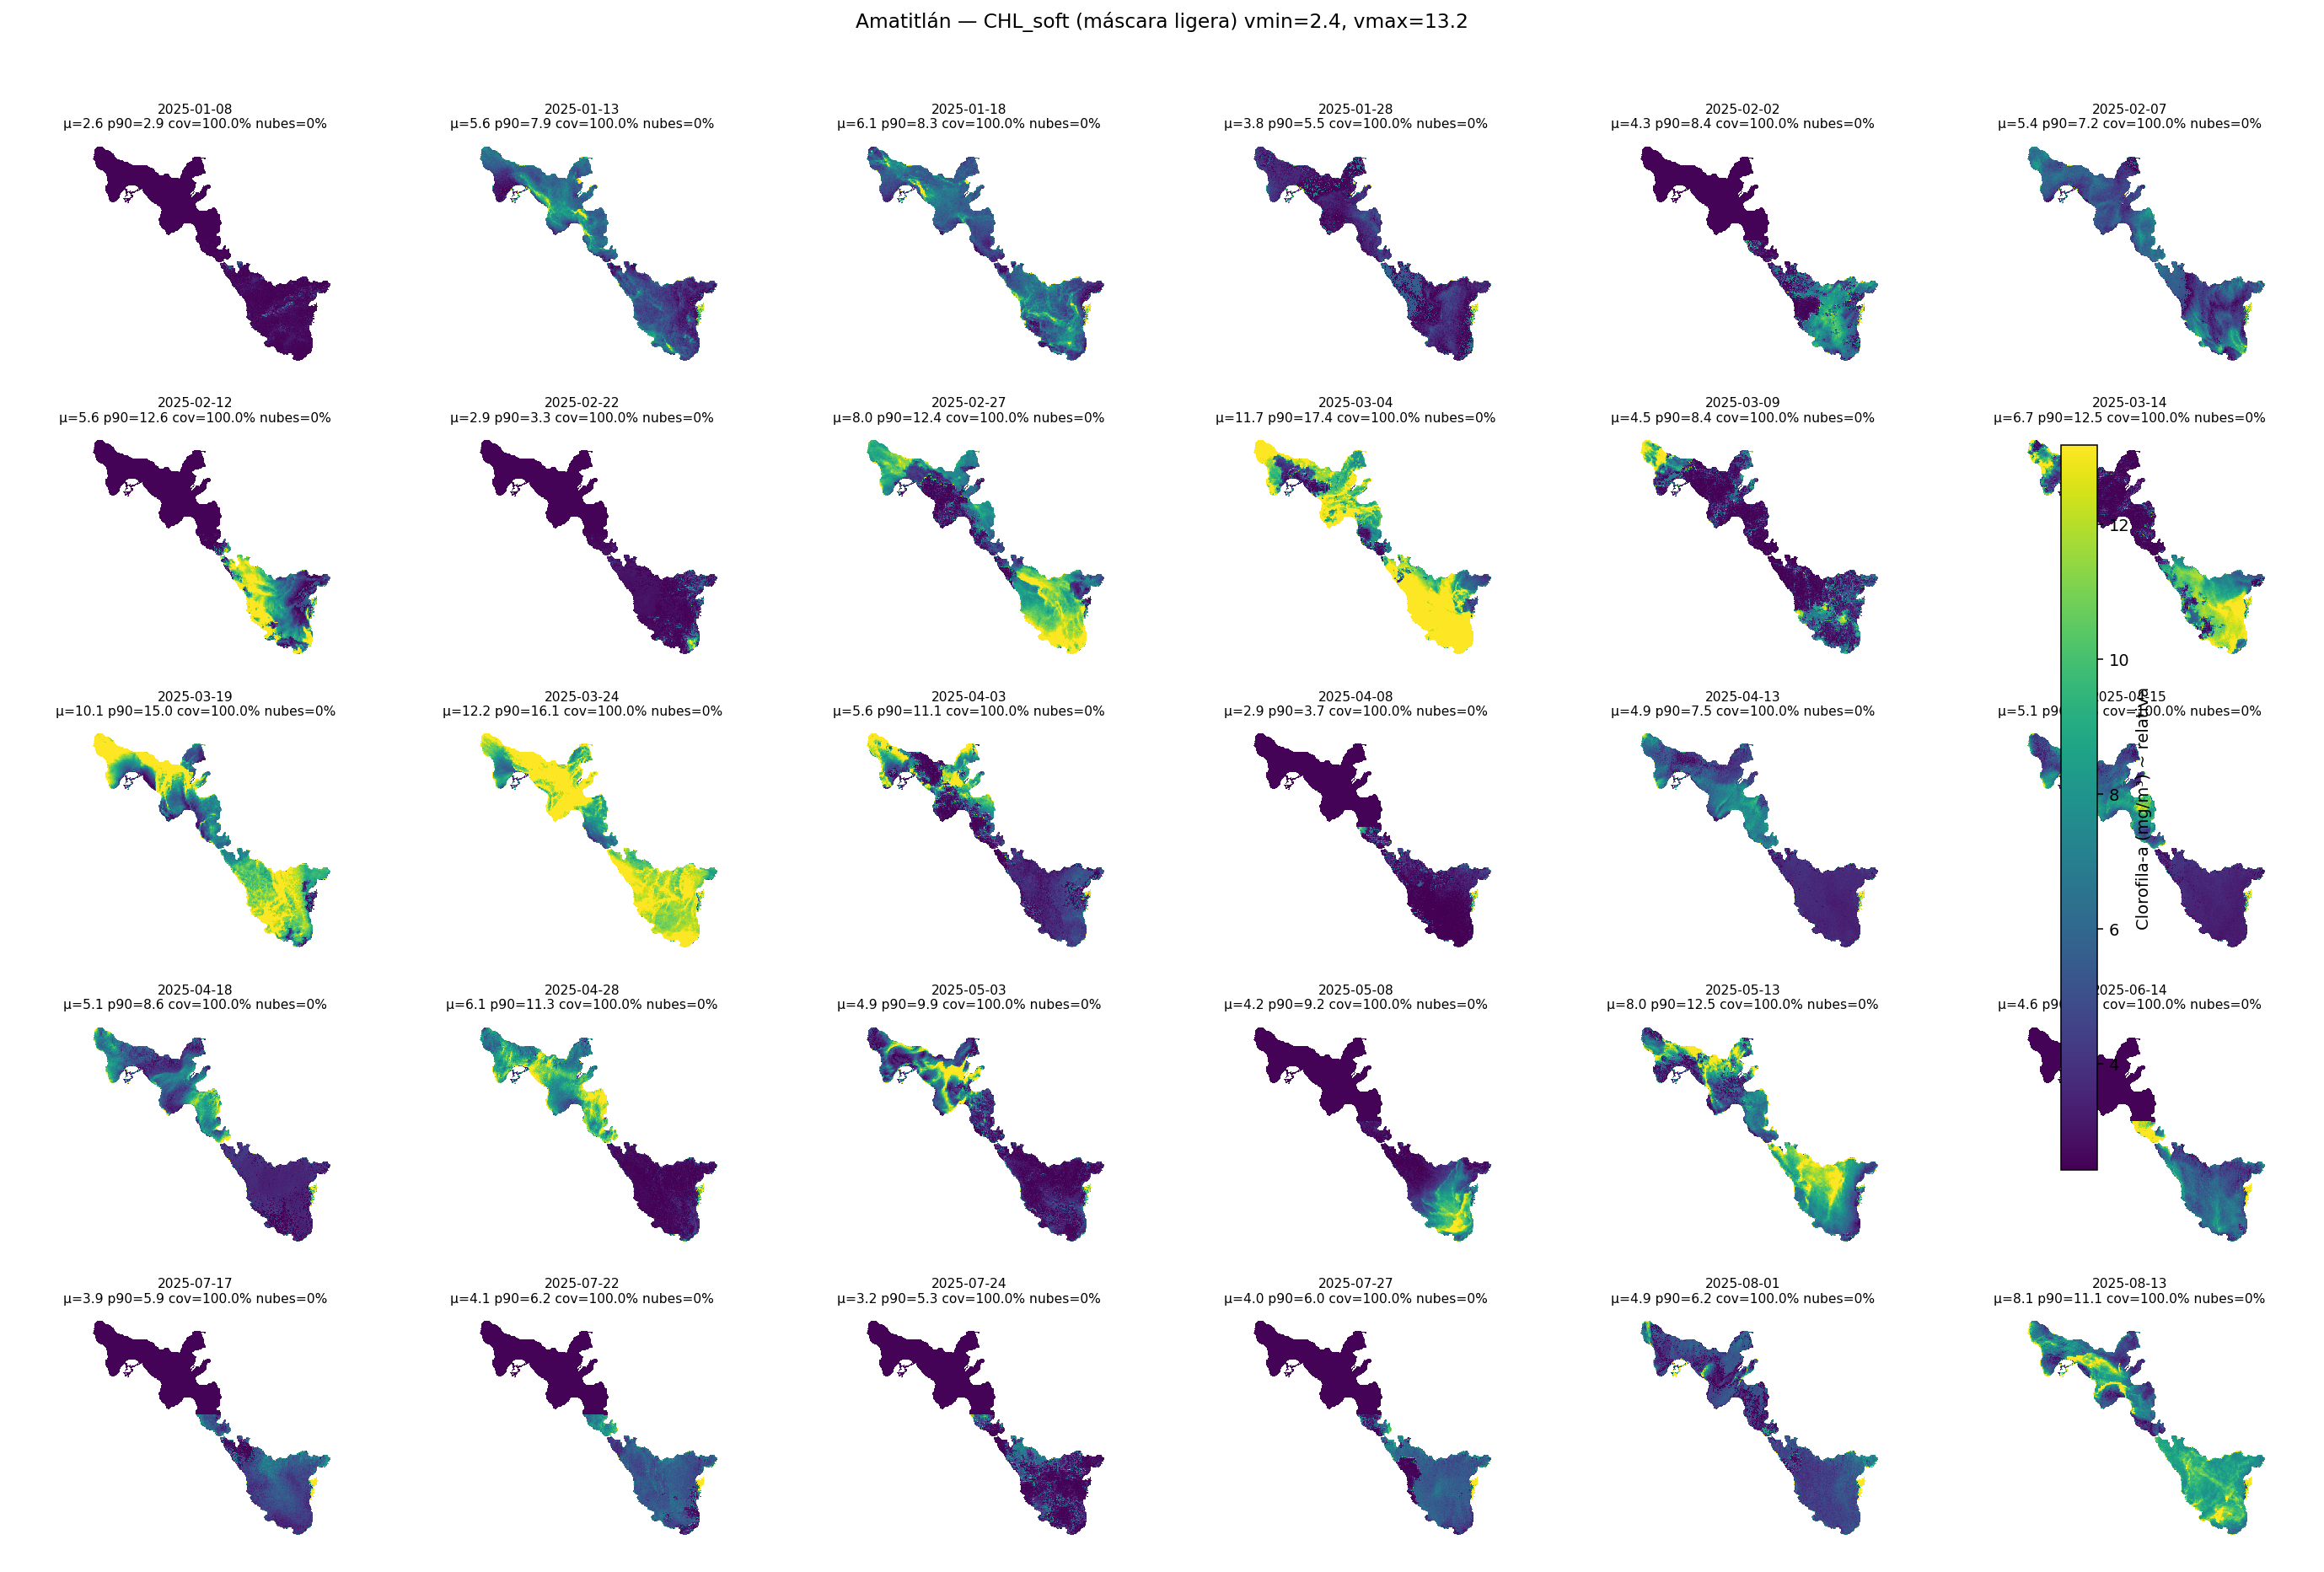

In [35]:
LAKE_NAME = "Amatitlán"
L2A_DIR   = "descargas_amatitlan"
OUT_DIR   = "chl_soft_out_amati"
NCOLS     = 6

SCL_CLOUDS = {3,8,9,10,11}
ERODE_WATER_PIXELS = 0         # 0–2 limpia orillas
BRIDGE_DILATE_PX    = 0        # 0–2 para “puentear” cuellos estrechos ANTES del voto
MIN_COMPONENT_FRAC  = 0.10      # conserva componentes >=10% del mayor (dos cuencas)
WATER_COUNT_MIN     = 1        # píxeles marcados agua en >=1 fecha entran al lake_mask

V_CLAMP = (0, 200)
P_LOW, P_HIGH = 5, 95

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

def list_openEO(root):
    items=[]
    for p in sorted(glob.glob(os.path.join(root, "openEO_*Z.tif"))):
        m = DATE_RE.search(os.path.basename(p))
        if m: items.append((m.group(1), p))
    return items

def safe_div(a,b):
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.true_divide(a,b); out[~np.isfinite(out)] = 0.0
    return out

def find_band_safe(src, idx):
    return src.read(idx).astype(np.float32) if (1 <= idx <= src.count) else None

def find_scl_band(src):
    try:
        desc = getattr(src, "descriptions", None)
        if desc:
            for i, d in enumerate(desc, start=1):
                if d and ("scl" in d.lower() or "scene classification" in d.lower()):
                    return i
    except Exception:
        pass
    return 10 if src.count >= 10 else None

def cloud_mask_from_SCL(scl):
    scl = np.where(np.isfinite(scl), scl, -1).astype(np.int16)
    return np.isin(scl, list(SCL_CLOUDS))

def water_mask_from_SCL(scl):
    scl = np.where(np.isfinite(scl), scl, -1).astype(np.int16)
    return (scl == 6)

def water_mask_from_indices(B02,B03,B04,B08,B11,B12):
    def norm(x):
        if x is None: return None
        if np.nanpercentile(x,99) > 1.5: x = x/10000.0
        return np.clip(x,0,1)
    B02,B03,B04,B08,B11,B12 = map(norm,(B02,B03,B04,B08,B11,B12))
    ndvi  = safe_div((B08 - B04), (B08 + B04)) if (B08 is not None) else None
    mndwi = safe_div((B03 - B11), (B03 + B11)) if (B11 is not None) else None
    ndwi  = safe_div((B03 - (B08 if B08 is not None else B04)),
                     (B03 + (B08 if B08 is not None else B04)))
    conds=[]
    if mndwi is not None: conds.append(mndwi > 0.42)
    if ndwi  is not None: conds.append(ndwi  > 0.40)
    if ndvi  is not None: conds.append(ndvi  < -0.20)
    if not conds: return np.zeros(B03.shape, dtype=bool)
    water = conds[0]
    for c in conds[1:]: water |= c
    return water

def keep_big_components(mask, min_frac=0.10):
    if not mask.any(): return mask
    lab, num = ndi.label(mask.astype(np.uint8))
    if num <= 1: return mask
    sizes = ndi.sum(mask, lab, index=range(1, num+1)).astype(np.int64)
    max_area = float(sizes.max())
    keep_ids = [i+1 for i, s in enumerate(sizes) if (s >= min_frac*max_area)]
    return np.isin(lab, keep_ids)

def fill_holes(mask):
    return ndi.binary_fill_holes(mask).astype(bool)

def reproject_like(src_arr, src_tr, src_crs, dst_shape, dst_tr, dst_crs,
                   order=Resampling.nearest, nodata=0):
    out = np.full(dst_shape, nodata, dtype=src_arr.dtype)
    reproject(source=src_arr, destination=out,
              src_transform=src_tr, src_crs=src_crs,
              dst_transform=dst_tr, dst_crs=dst_crs,
              resampling=order, src_nodata=nodata, dst_nodata=nodata)
    return out

def compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05):
    tiny = 1e-6
    with np.errstate(divide='ignore', invalid='ignore'):
        ndci = (rrs_b05 - rrs_b04) / (rrs_b05 + rrs_b04 + tiny)
        oc3  = np.log10((rrs_b02 + tiny) / (rrs_b03 + tiny))
    chl_low  = 10 ** (0.4 + 3.0 * oc3)
    chl_high = 40.0 * ndci + 2.0
    chl_soft = np.where(ndci > 0, chl_high, chl_low)
    chl_soft = np.clip(chl_soft, V_CLAMP[0], V_CLAMP[1])
    chl_soft[~np.isfinite(chl_soft)] = np.nan
    return ndci, oc3, chl_soft

items = list_openEO(L2A_DIR)
if not items:
    raise SystemExit(f"No encontré multibandas openEO_*Z.tif en {L2A_DIR}")

with rasterio.open(items[0][1]) as src0:
    base_H, base_W = src0.height, src0.width
    base_tr, base_crs = src0.transform, src0.crs

water_count = np.zeros((base_H, base_W), dtype=np.uint16)

for _, mb in items:
    with rasterio.open(mb) as src:
        tr, crs = src.transform, src.crs
        scl_idx = find_scl_band(src)
        scl = None
        if scl_idx is not None:
            try: scl = src.read(scl_idx).astype(np.float32)
            except Exception: pass

        if scl is not None:
            water = water_mask_from_SCL(scl)
        else:
            B02 = find_band_safe(src,1); B03 = find_band_safe(src,2); B04 = find_band_safe(src,3)
            B08 = find_band_safe(src,7); B11 = find_band_safe(src,8); B12 = find_band_safe(src,9)
            water = water_mask_from_indices(B02,B03,B04,B08,B11,B12)

        water_r = reproject_like(water.astype(np.uint8), tr, crs,
                                 (base_H, base_W), base_tr, base_crs,
                                 order=Resampling.nearest, nodata=0).astype(bool)

        if BRIDGE_DILATE_PX > 0 and water_r.any():
            water_r = ndi.binary_dilation(water_r, iterations=BRIDGE_DILATE_PX)

        water_r = keep_big_components(water_r, MIN_COMPONENT_FRAC)
        water_r = fill_holes(water_r)

        if ERODE_WATER_PIXELS > 0 and water_r.any():
            water_r = ndi.binary_opening(water_r, iterations=ERODE_WATER_PIXELS)

        water_count += water_r.astype(np.uint16)

lake_mask = (water_count >= WATER_COUNT_MIN)
lake_mask = keep_big_components(lake_mask, MIN_COMPONENT_FRAC)
lake_mask = fill_holes(lake_mask)

rows, stacks = [], []
for date_iso, mb in items:
    with rasterio.open(mb) as src:
        tr, crs = src.transform, src.crs
        lake_m = reproject_like(lake_mask.astype(np.uint8), base_tr, base_crs,
                                (src.height, src.width), tr, crs,
                                order=Resampling.nearest, nodata=0).astype(bool)

        b02 = src.read(1).astype(np.float32)
        b03 = src.read(2).astype(np.float32)
        b04 = src.read(3).astype(np.float32)
        b05 = src.read(4).astype(np.float32)

        scl = None
        scl_idx = find_scl_band(src)
        if scl_idx is not None:
            try: scl = src.read(scl_idx).astype(np.float32)
            except Exception: pass
        cloud_mask = cloud_mask_from_SCL(scl) if scl is not None else np.zeros_like(lake_m, dtype=bool)

        rrs_b02 = (b02/10000.0).clip(0,1)
        rrs_b03 = (b03/10000.0).clip(0,1)
        rrs_b04 = (b04/10000.0).clip(0,1)
        rrs_b05 = (b05/10000.0).clip(0,1)

        _, _, chl = compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05)
        valid_mask = lake_m & (~cloud_mask)
        chl_masked = np.where(valid_mask, chl, np.nan)
        chl_masked[~lake_m] = np.nan

        lake_px = int(lake_m.sum())
        valid   = chl_masked[np.isfinite(chl_masked)]
        clouds_pct = float((cloud_mask & lake_m).sum())/max(lake_px,1)*100.0
        coverage_pct = 100.0 * valid.size / max(lake_px,1)

        rows.append(dict(
            date=date_iso, lake_px=lake_px, valid_px=int(valid.size),
            clouds_pct_over_lake=clouds_pct, coverage_pct=coverage_pct,
            chl_mean=float(np.nanmean(valid)) if valid.size else np.nan,
            chl_median=float(np.nanmedian(valid)) if valid.size else np.nan,
            chl_p90=float(np.nanpercentile(valid,90)) if valid.size else np.nan,
            chl_max=float(np.nanmax(valid)) if valid.size else np.nan
        ))

        profile = src.profile
        profile.update(count=1, dtype="float32", nodata=np.nan, compress="lzw")
        out_path = os.path.join(OUT_DIR, f"openEO_{date_iso}Z_chl_soft.tif")
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(chl_masked.astype(np.float32), 1)

        stacks.append((date_iso, chl_masked))

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
csv_path = os.path.join(OUT_DIR, f"resumen_{LAKE_NAME}_chl_soft.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Guardado: {csv_path}")

vals = [a[np.isfinite(a)] for _,a in stacks if np.isfinite(a).any()]
if vals:
    allv = np.concatenate(vals)
    vmin = max(V_CLAMP[0], np.percentile(allv, P_LOW))
    vmax = min(V_CLAMP[1], np.percentile(allv, P_HIGH))
    if vmin >= vmax: vmax = vmin + 1.0
else:
    vmin, vmax = 0.0, 10.0
print(f"Escala global CHL_soft: vmin={vmin:.1f}, vmax={vmax:.1f}")

n = len(stacks)
ncols = min(NCOLS, n); nrows = int(np.ceil(n / ncols))
cmap = plt.cm.viridis.copy(); cmap.set_bad(alpha=0.0)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3*ncols, 2.7*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL_soft (máscara ligera) vmin={vmin:.1f}, vmax={vmax:.1f}", y=0.995)
im_for_cbar=None
for i, (d, arr) in enumerate(stacks):
    r,c = divmod(i, ncols); ax = axes[r][c]
    im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, interpolation='none'); im_for_cbar = im
    ax.set_axis_off()
    m = df.loc[df["date"]==d].iloc[0]
    ax.set_title(f"{d}\nμ={m['chl_mean']:.1f} p90={m['chl_p90']:.1f} cov={m['coverage_pct']:.1f}% nubes={m['clouds_pct_over_lake']:.0f}%", fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
if im_for_cbar is not None:
    cb = fig.colorbar(im_for_cbar, ax=axes, fraction=0.02, pad=0.02); cb.set_label("Clorofila-a (mg/m³) ~ relativa")
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()

## **5. Conviertalo en arreglos de numpy para analizarlos**
## **6. Haga un análisis temporal para eso:**
    6.1. Calcula un índice promedio de cianobacteria por lago y por fecha.
    6.2. Visualiza la evolución temporal en un gráfico de línea por lago.
    6.3. Identifica posibles picos de floración y fechas críticas.


=== Atitlán ===


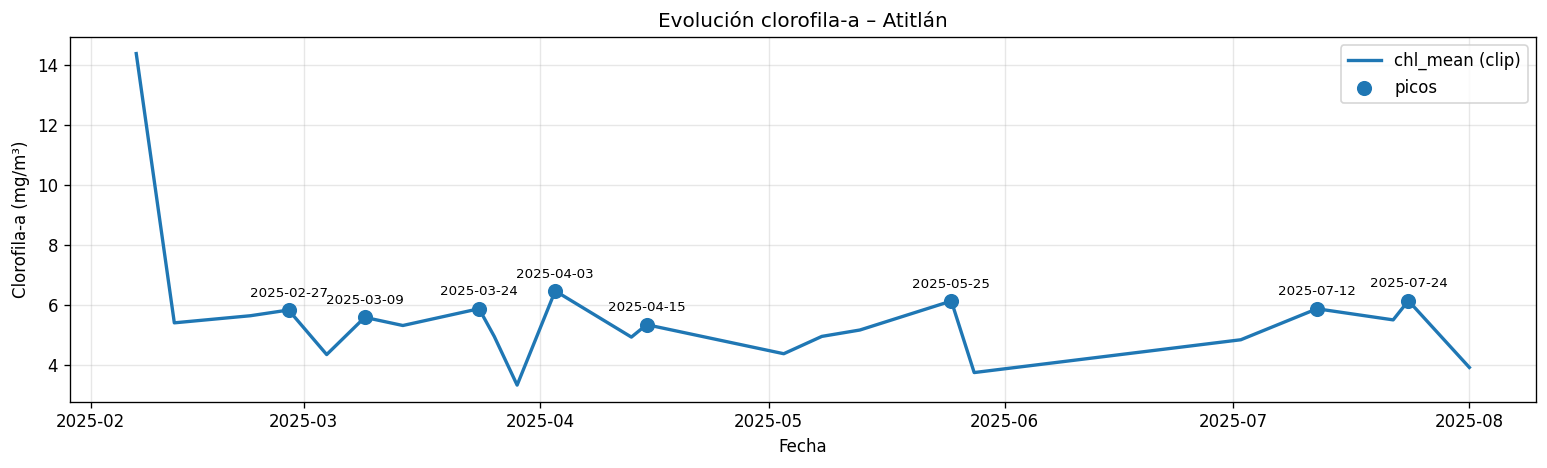

Picos detectados en Atitlán (8):
 • 2025-02-27  index_promedio≈5.84
 • 2025-03-09  index_promedio≈5.60
 • 2025-03-24  index_promedio≈5.88
 • 2025-04-03  index_promedio≈6.48
 • 2025-04-15  index_promedio≈5.35
 • 2025-05-25  index_promedio≈6.14
 • 2025-07-12  index_promedio≈5.88
 • 2025-07-24  index_promedio≈6.15

=== Amatitlán ===


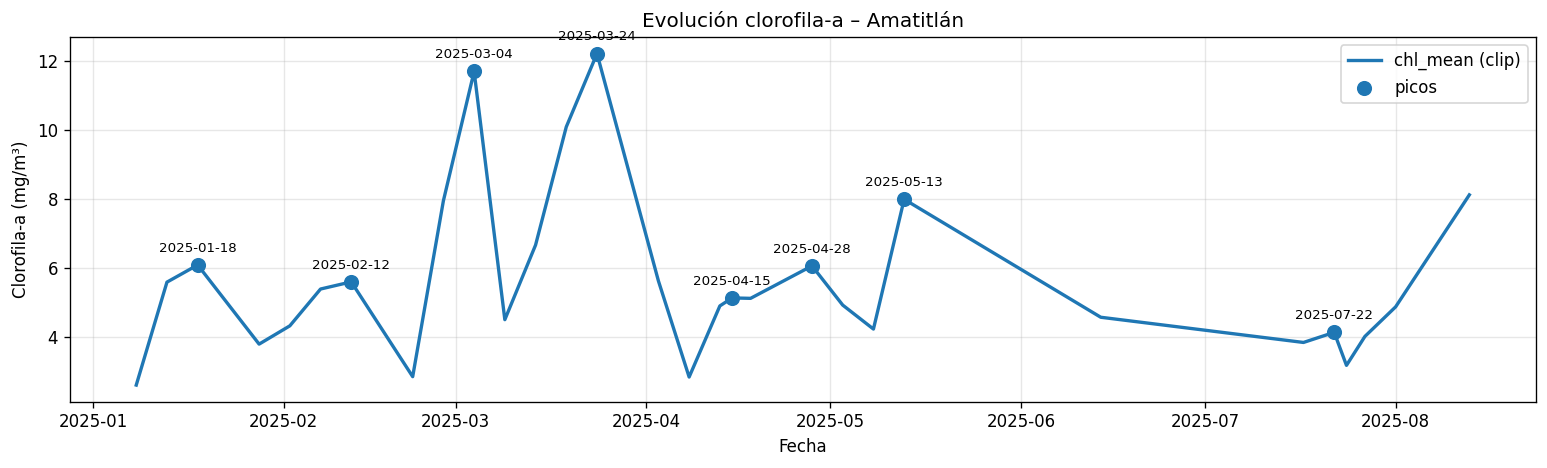

Picos detectados en Amatitlán (8):
 • 2025-01-18  index_promedio≈6.10
 • 2025-02-12  index_promedio≈5.61
 • 2025-03-04  index_promedio≈11.69
 • 2025-03-24  index_promedio≈12.21
 • 2025-04-15  index_promedio≈5.14
 • 2025-04-28  index_promedio≈6.07
 • 2025-05-13  index_promedio≈8.00
 • 2025-07-22  index_promedio≈4.15

Índice promedio de cianobacteria por lago y por fecha:
     lake       date  index_promedio
Amatitlán 2025-01-08        2.622176
Amatitlán 2025-01-13        5.599992
Amatitlán 2025-01-18        6.096903
Amatitlán 2025-01-28        3.807109
Amatitlán 2025-02-02        4.335753
Amatitlán 2025-02-07        5.400339
Amatitlán 2025-02-12        5.607627
Amatitlán 2025-02-22        2.866281
Amatitlán 2025-02-27        7.954280
Amatitlán 2025-03-04       11.693450
Amatitlán 2025-03-09        4.514408
Amatitlán 2025-03-14        6.672243
Amatitlán 2025-03-19       10.089820
Amatitlán 2025-03-24       12.210559
Amatitlán 2025-04-03        5.634642
Amatitlán 2025-04-08        2.85553

In [ ]:
LAKES = {
    "Atitlán":   "chl_soft_out_ati",
    "Amatitlán": "chl_soft_out_amati",
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

def find_chl_tifs(lake_root):
    files = glob.glob(os.path.join(lake_root, "**", "*_chl_soft.tif"), recursive=True)
    items = []
    for p in sorted(files):
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    if not items:
        raise ValueError(f"No se encontraron *_chl_soft.tif en {lake_root}")
    items.sort(key=lambda t: t[0])
    return [d.isoformat() for d,_ in items], [p for _,p in items]

def load_cube(paths):
    with rasterio.open(paths[0]) as src0:
        H, W = src0.height, src0.width
    cube = np.full((len(paths), H, W), np.nan, dtype=np.float32)
    for i,p in enumerate(paths):
        with rasterio.open(p) as src:
            a = src.read(1).astype(np.float32)
            if src.nodata is not None:
                a[a==src.nodata] = np.nan
            cube[i] = a
    return cube

def per_date_stats(cube):
    T = cube.shape[0]
    flat = cube.reshape(T, -1)
    return (
        np.nanmean(flat, axis=1),        
        np.nanmedian(flat, axis=1),
        np.nanpercentile(flat, 90, axis=1),
        np.nanstd(flat, axis=1),
        np.sum(np.isfinite(flat), axis=1).astype(int),
    )

def detect_local_peaks(y):
    """
    Devuelve índices de picos locales estrictos:
      - y[i] > y[i-1] y y[i] > y[i+1]
      - Soporta mesetas (elige el centro)
    """
    n = len(y)
    if n < 3: return []
    peaks = []
    i = 1
    while i < n-1:
        if y[i] > y[i-1] and y[i] > y[i+1]:
            peaks.append(i); i += 1; continue
        if y[i] > y[i-1] and y[i] == y[i+1]:
            j = i
            while j+1 < n and y[j] == y[j+1]:
                j += 1
            if j < n-1 and y[j] > y[j+1]:
                peaks.append((i+j)//2)
            i = j+1; continue
        i += 1
    return peaks

all_rows = []   

for lake, root in LAKES.items():
    print(f"\n=== {lake} ===")
    dates, paths = find_chl_tifs(root)
    cube = load_cube(paths)

    mean, median, p90, std, water_px = per_date_stats(cube)

    idx_dt = pd.to_datetime(dates)
    df = pd.DataFrame({"index_promedio": mean}, index=idx_dt).sort_index()
    df.index.name = "date"

    tmp = df.copy().reset_index()
    tmp["lake"] = lake
    all_rows.append(tmp[["lake","date","index_promedio"]])

    y = np.clip(df["index_promedio"].values, 0, 500)
    pk = detect_local_peaks(y)

    plt.figure(figsize=(13,4), dpi=120)
    plt.plot(df.index, y, label="chl_mean (clip)", linewidth=2)
    if pk:
        plt.scatter(df.index[pk], y[pk], s=65, zorder=3, label="picos")
        for i in pk:
            plt.annotate(df.index[i].strftime("%Y-%m-%d"),
                         (df.index[i], y[i]), textcoords="offset points",
                         xytext=(0,8), ha="center", fontsize=8)
    plt.title(f"Evolución clorofila-a – {lake}")
    plt.xlabel("Fecha"); plt.ylabel("Clorofila-a (mg/m³)")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.show()

    if pk:
        print(f"Picos detectados en {lake} ({len(pk)}):")
        for i in pk:
            print(f" • {df.index[i].date()}  index_promedio≈{float(y[i]):.2f}")
    else:
        print("⚠️ No se encontraron picos.")

indice_cianobacteria = pd.concat(all_rows, ignore_index=True).sort_values(["lake","date"])
print("\nÍndice promedio de cianobacteria por lago y por fecha:")
print(indice_cianobacteria.to_string(index=False))

out_csv = "indice_cianobacteria_por_lago.csv"
indice_cianobacteria.to_csv(out_csv, index=False)
print(f"\nCSV guardado: {out_csv}")

## **7. Haga un análisis espacial para esto:**
    7.1. Mapea la distribución de cianobacteria dentro de cada lago usando matplotlib o folium
    (genera un mapa interactivo)

In [ ]:
# ===============================================================
# Folium (Jupyter): Mapas interactivos de CHL_soft por lago/fecha
# - Usa paleta VIRIDIS (como tus paneles)
# - Filtra por fechas de picos y se queda con Top-K por promedio
# - Genera 1 HTML por lago + 1 comparativo lado a lado
# ===============================================================
import os, glob, re, math
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform_bounds
import folium
from folium import raster_layers
import branca
from IPython.display import IFrame, display
from matplotlib import cm, colors as mcolors

LAKES = {
    "Atitlán":   "chl_soft_out_ati",    
    "Amatitlán": "chl_soft_out_amati", 
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

PEAK_DATES = {
    "Amatitlán": [
        "2025-01-18","2025-02-12","2025-03-04","2025-03-24",
        "2025-04-15","2025-04-28","2025-05-13","2025-07-22",
    ],
    "Atitlán": [
        "2025-02-27","2025-03-09","2025-03-24","2025-04-03",
        "2025-04-15","2025-05-25","2025-07-12","2025-07-24",
    ],
}
USE_TOP_K = 4                
MAX_DOWNSAMPLED_DIM = 800    
OVERLAY_OPACITY = 0.72

def find_chl_tifs(lake_root):
    files = glob.glob(os.path.join(lake_root, "**", "*_chl_soft.tif"), recursive=True)
    items = []
    for p in sorted(files):
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    if not items:
        raise FileNotFoundError(f"No *_chl_soft.tif found in {lake_root}")
    items.sort(key=lambda t: t[0])
    dates = [d.isoformat() for d,_ in items]
    paths = [p for _,p in items]
    return dates, paths

def read_raster_and_bounds(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        b = src.bounds
        if src.crs and src.crs.to_epsg() != 4326:
            west, south, east, north = transform_bounds(src.crs, "EPSG:4326", *b, densify_pts=21)
        else:
            west, south, east, north = b.left, b.bottom, b.right, b.top
        H, W = arr.shape
        if max(H, W) > MAX_DOWNSAMPLED_DIM:
            step = int(math.ceil(max(H, W) / MAX_DOWNSAMPLED_DIM))
            arr = arr[::step, ::step]
        return arr, (south, west, north, east)

def pick_dates_by_top_mean(dates, paths, allowed_dates=None, top_k=4):
    """Filtra por allowed_dates y devuelve las top_k por media espacial (ordenadas por fecha)."""
    recs = []
    for d, p in zip(dates, paths):
        if allowed_dates is not None and d not in allowed_dates:
            continue
        a, _ = read_raster_and_bounds(p)
        m = float(np.nanmean(a)) if np.isfinite(a).any() else -np.inf
        recs.append((d, p, m))
    if not recs:
        return [], []
    recs.sort(key=lambda t: t[2], reverse=True)
    if top_k and top_k > 0:
        recs = recs[:top_k]
    recs.sort(key=lambda t: t[0]) 
    sel_dates = [r[0] for r in recs]
    sel_paths = [r[1] for r in recs]
    return sel_dates, sel_paths

def make_overlay_image(arr, vmin, vmax, mpl_cmap):
    """Mapea el array -> RGBA uint8 (vectorizado, compatible con Folium ImageOverlay)."""
    a = np.array(arr, copy=True)
    mask = ~np.isfinite(a)
    a = np.clip(a, vmin, vmax)
    norm = (a - vmin) / (vmax - vmin + 1e-9)
    rgba = mpl_cmap(norm)          
    rgba[mask] = (0,0,0,0)
    return (rgba * 255).astype(np.uint8)

def mpl_to_branca_colormap(mpl_cmap, vmin, vmax, n=256, caption="Clorofila-a (mg/m³)"):
    stops = [mpl_cmap(i/(n-1)) for i in range(n)]
    hex_colors = [mcolors.to_hex(c) for c in stops]   
    col = branca.colormap.LinearColormap(colors=hex_colors, vmin=vmin, vmax=vmax)
    col.caption = caption
    return col

def lake_map(lake_name, lake_root, out_html, peak_dates_dict, top_k=4):
    all_dates, all_paths = find_chl_tifs(lake_root)
    allowed = set(peak_dates_dict.get(lake_name, [])) if peak_dates_dict else None
    dates, paths = pick_dates_by_top_mean(all_dates, all_paths,
                                          allowed_dates=allowed, top_k=top_k)
    if not dates:
        raise ValueError(f"No hay fechas seleccionadas para {lake_name}. Revisa PEAK_DATES/rutas.")
    vals, bounds = [], []
    for p in paths:
        a, b = read_raster_and_bounds(p)
        if np.isfinite(a).any(): vals.append(a[np.isfinite(a)])
        bounds.append(b)
    concat = np.concatenate(vals) if vals else np.array([0,1], dtype=float)
    vmin = float(np.nanpercentile(concat, 5))
    vmax = float(np.nanpercentile(concat, 95))
    if vmax <= vmin: vmax = vmin + 1.0

    mpl_cmap   = cm.get_cmap("viridis")
    branca_cmap = mpl_to_branca_colormap(mpl_cmap, vmin, vmax)

    south, west, north, east = bounds[-1]
    center = [(south+north)/2, (west+east)/2]
    m = folium.Map(location=center, zoom_start=11,
                   tiles="cartodbpositron", control_scale=True)

    for d, p, b in zip(dates, paths, bounds):
        a, _ = read_raster_and_bounds(p)
        img = make_overlay_image(a, vmin, vmax, mpl_cmap)
        s, w, n, e = b
        raster_layers.ImageOverlay(
            image=img,
            bounds=[[s, w], [n, e]],
            opacity=OVERLAY_OPACITY,
            name=d,
            interactive=False,
            zindex=1,
            mercator_project=True,
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    branca_cmap.add_to(m)
    m.save(out_html)
    return out_html, dates

def build_comparative_html(html_left, html_right, title="Mapas comparativos de cianobacteria"):
    comp = "mapa_cianobacteria_comparativo.html"
    template = f"""<!DOCTYPE html>
<html lang="es"><head>
<meta charset="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1"/>
<title>{title}</title>
<style>
 body {{ margin:0; font-family: system-ui, -apple-system, Segoe UI, Roboto, sans-serif; }}
 .wrap {{ display:flex; flex-wrap:wrap; gap:8px; padding:8px; }}
 .panel {{ flex:1 1 560px; min-width:320px; height:80vh; border:1px solid #ddd; border-radius:10px; overflow:hidden; box-shadow:0 1px 4px rgba(0,0,0,.06); }}
 .head {{ padding:8px 10px; font-weight:600; }}
 .frame {{ width:100%; height:calc(100% - 36px); border:0; }}
</style></head><body>
<div class="wrap">
  <div class="panel"><div class="head">Mapa 1</div><iframe class="frame" src="{html_left}"></iframe></div>
  <div class="panel"><div class="head">Mapa 2</div><iframe class="frame" src="{html_right}"></iframe></div>
</div></body></html>"""
    with open(comp, "w", encoding="utf-8") as f:
        f.write(template)
    return comp

outputs = {}
selected_dates = {}
for lake, root in LAKES.items():
    out_html = f"mapa_cianobacteria_{lake.replace('í','i').replace('á','a')}.html"
    html_path, used_dates = lake_map(lake, root, out_html, PEAK_DATES, top_k=USE_TOP_K)
    outputs[lake] = html_path
    selected_dates[lake] = used_dates
    print(f"{lake}: fechas usadas ({len(used_dates)}): {used_dates}")
    display(IFrame(src=html_path, width="100%", height=600))

if len(outputs) >= 2:
    lakes_list = list(outputs.keys())
    comp = build_comparative_html(outputs[lakes_list[0]], outputs[lakes_list[1]])
    print("Comparativo guardado:", comp)
    display(IFrame(src=comp, width="100%", height=640))
else:
    print("Solo hay un lago; no se generó comparativo.")

/var/folders/fd/7pj5mc8x0pn8jx56z039h30m0000gn/T/ipykernel_4258/3229635029.py:128: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mpl_cmap   = cm.get_cmap("viridis")


Atitlán: fechas usadas (4): ['2025-03-24', '2025-04-03', '2025-05-25', '2025-07-24']


Amatitlán: fechas usadas (4): ['2025-01-18', '2025-03-04', '2025-03-24', '2025-05-13']


Comparativo guardado: mapa_cianobacteria_comparativo.html


## **Inciso 8** julio andres pls usa los dos de soft tanto de ati como amati para que funcionen igual.


=== Atitlán ===
✅ Guardado CSV: diagnosticos_corr/corr_indices_Atitlán.csv


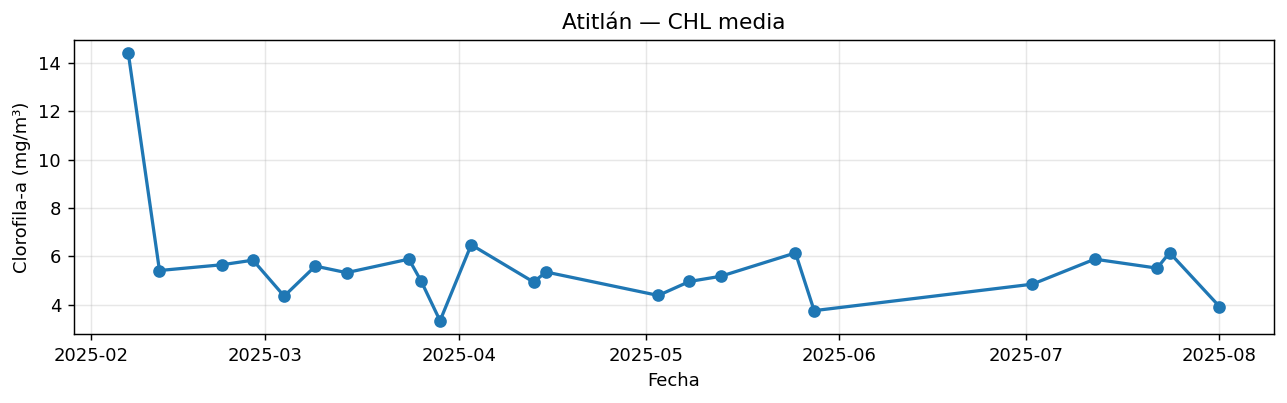

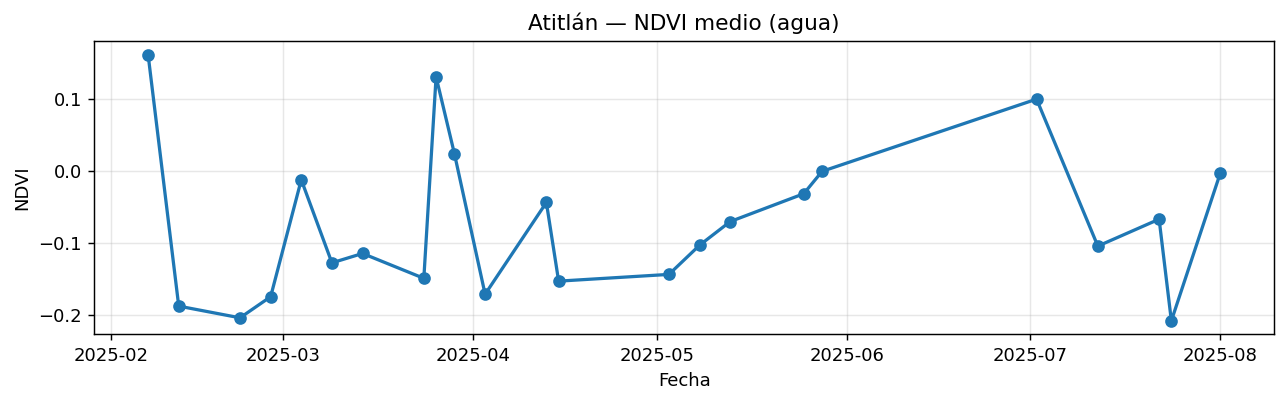

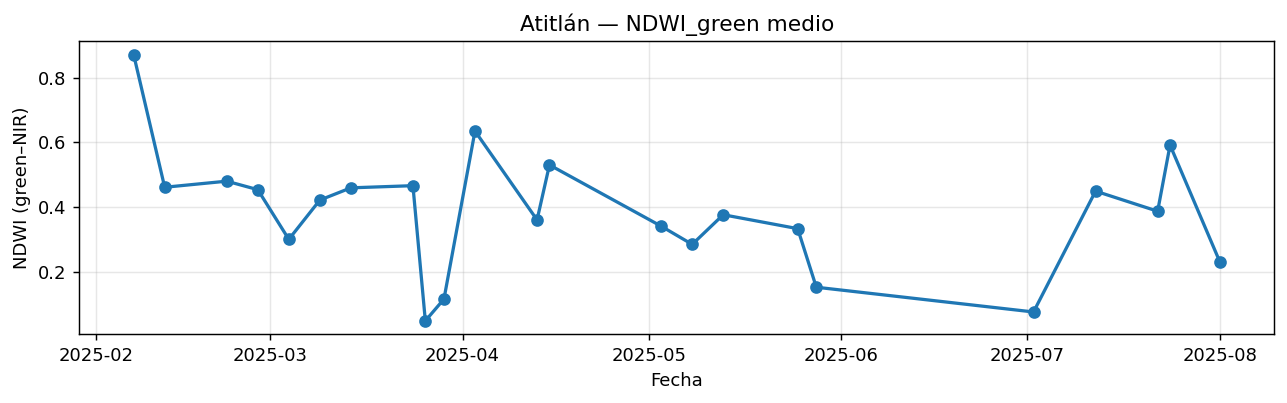

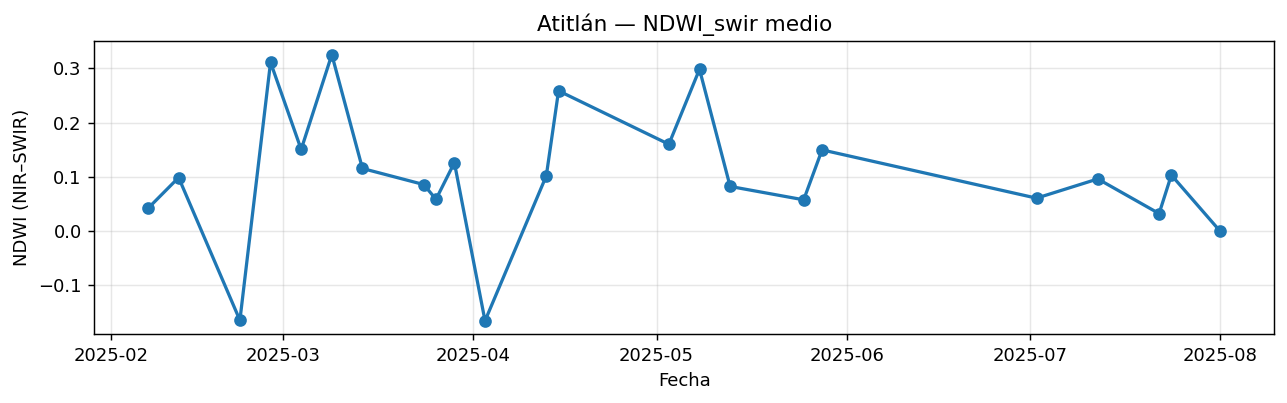

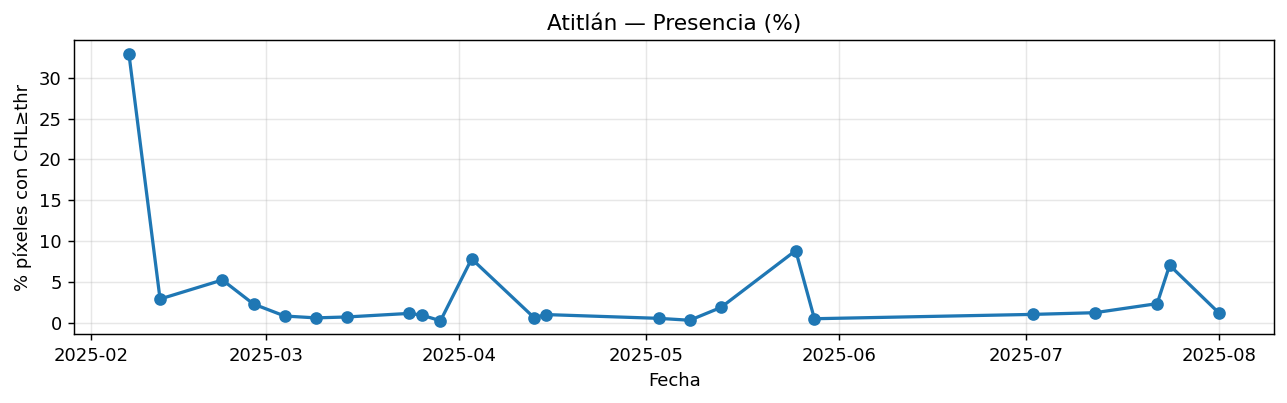

📈 Atitlán — Correlación (medias por fecha):
  CHL vs NDVI   -> Pearson=0.247  Spearman=-0.478
  CHL vs NDWI_g -> Pearson=0.759     Spearman=0.798
  CHL vs NDWI_s -> Pearson=-0.169     Spearman=-0.301


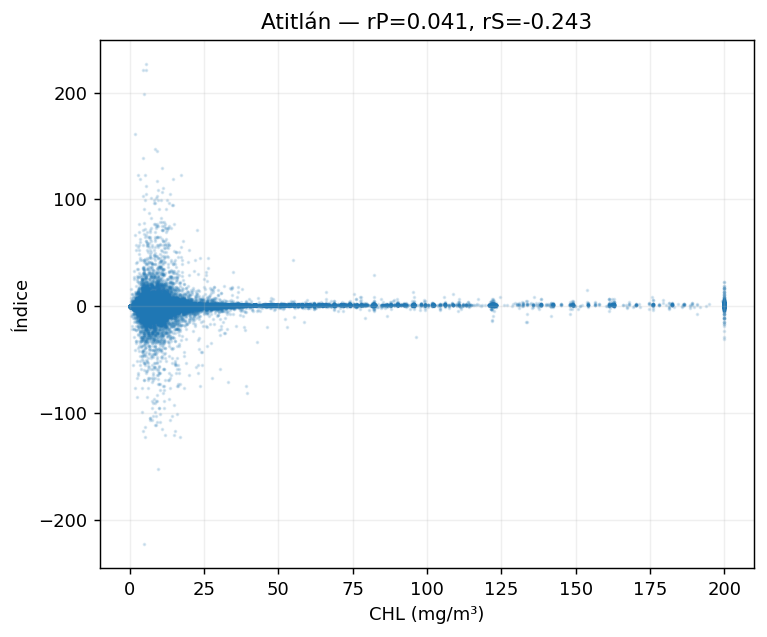

  ✔ Guardado: diagnosticos_corr/scatter_CHL_vs_NDVI_Atitlán.png


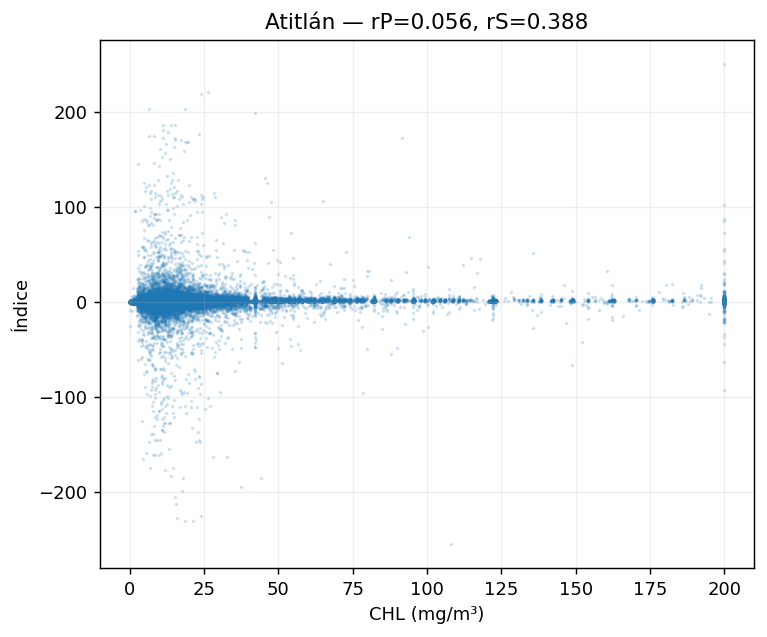

  ✔ Guardado: diagnosticos_corr/scatter_CHL_vs_NDWI_green_Atitlán.png


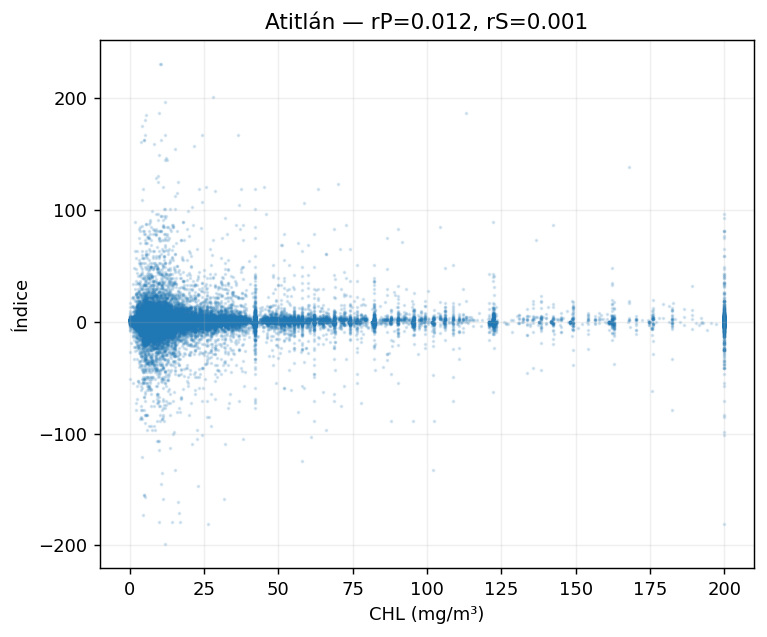

  ✔ Guardado: diagnosticos_corr/scatter_CHL_vs_NDWI_swir_Atitlán.png

=== Amatitlán ===


IndexError: band index 10 out of range (not in (1, 2, 3, 4, 5, 6, 7, 8, 9))

In [48]:
import os, re, glob
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
LAKES = {
    "Atitlán": {
        "chl_root": "chl_soft_out_ati",
        "chl_pattern": "*_chl_soft.tif",
        "l2a_root": "descargas_atitlan_fechas",
        "water_from_scl": True,
        "presence_thr": 10.0
    },
    "Amatitlán": {
        "chl_root": "chl_soft_out_amati",
        "chl_pattern": "*_chl_soft.tif",
        "l2a_root": "descargas_amatitlan",
        "water_from_scl": True,
        "presence_thr": 10.0
    }
}

OUT_DIR = "diagnosticos_corr"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)

# ---------------- UTILIDADES ----------------
def safe_nd(a, b):
    out = (a - b) / np.where((a + b) == 0, np.nan, (a + b))
    out[~np.isfinite(out)] = np.nan
    return out.astype(np.float32)

def list_by_date(root, pattern):
    pats = [os.path.join(root, pattern), os.path.join(root, "**", pattern)]
    files = []
    for p in pats:
        files.extend(glob.glob(p, recursive=True))
    items = []
    for f in sorted(set(files)):
        m = DATE_RE.search(os.path.basename(f))
        if m:
            items.append((m.group(1), f))
    items.sort(key=lambda t: t[0])
    return items

def find_l2a_for_date(l2a_root, date_iso):
    pat = f"**/openEO_{date_iso}Z.tif"
    cand = glob.glob(os.path.join(l2a_root, pat), recursive=True)
    return cand[0] if cand else None

def read_band(src, band_name):
    idx = {"B02":1, "B03":2, "B04":3, "B05":4, "B07":5, "B8A":6, "B08":7, "B11":8, "B12":9, "SCL":10}[band_name]
    a = src.read(idx).astype(np.float32)
    if src.nodata is not None:
        a[a == src.nodata] = np.nan
    return a

def reproject_like(src_arr, src_profile, dst_profile):
    out = np.full((dst_profile["height"], dst_profile["width"]), np.nan, dtype=np.float32)
    reproject(
        source=src_arr, destination=out,
        src_transform=src_profile["transform"], src_crs=src_profile["crs"],
        dst_transform=dst_profile["transform"], dst_crs=dst_profile["crs"],
        resampling=Resampling.bilinear,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return out

def sample_pairs(x, y, n=80000):
    m = np.isfinite(x) & np.isfinite(y)
    idx = np.where(m.ravel())[0]
    if idx.size == 0:
        return np.array([]), np.array([])
    if idx.size > n:
        idx = np.random.choice(idx, size=n, replace=False)
    xr = x.ravel()[idx]; yr = y.ravel()[idx]
    return xr, yr

def corr_pearson(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

def corr_spearman(x, y):
    from scipy.stats import spearmanr
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    r, _ = spearmanr(x[m], y[m])
    return float(r)

# ---------------- PIPELINE POR LAGO ----------------
for lake, cfg in LAKES.items():
    print(f"\n=== {lake} ===")
    chl_items = list_by_date(cfg["chl_root"], cfg["chl_pattern"])
    if not chl_items:
        print(f"⚠️ No encontré CHL en {cfg['chl_root']} con {cfg['chl_pattern']}.")
        continue

    rows = []
    # Acumuladores PAREADOS por índice (para no mezclar longitudes)
    scat = {
        "ndvi":   {"chl": [], "idx": []},
        "ndwi_g": {"chl": [], "idx": []},
        "ndwi_s": {"chl": [], "idx": []},
    }

    for date_iso, chl_path in chl_items:
        l2a_path = find_l2a_for_date(cfg["l2a_root"], date_iso)
        if not l2a_path:
            print(f"  ⚠️ {date_iso}: no hay L2A openEO_{date_iso}Z.tif. Salto fecha.")
            continue

        # 1) Abrir L2A y calcular índices
        with rasterio.open(l2a_path) as src:
            prof_l2a = src.profile
            B03 = read_band(src, "B03")
            B04 = read_band(src, "B04")
            B08 = read_band(src, "B08")
            B8A = read_band(src, "B8A")
            B11 = read_band(src, "B11")
            SCL = read_band(src, "SCL").astype(np.float32)

        NDVI    = safe_nd(B08, B04)
        NDWI_G  = safe_nd(B03, B08)   # McFeeters
        NDWI_S  = safe_nd(B8A, B11)   # Gao

        # 2) Leer CHL y alinear a la malla de L2A
        with rasterio.open(chl_path) as sc:
            chl = sc.read(1).astype(np.float32)
            if sc.nodata is not None:
                chl[chl == sc.nodata] = np.nan
            prof_chl = sc.profile

        if (prof_chl["transform"] != prof_l2a["transform"]) or (prof_chl["crs"] != prof_l2a["crs"]) \
           or (prof_chl["width"] != prof_l2a["width"]) or (prof_chl["height"] != prof_l2a["height"]):
            chl = reproject_like(chl, prof_chl, prof_l2a)

        # 3) Máscara de agua & CHL válido
        if cfg["water_from_scl"] and np.isfinite(SCL).any():
            water = (SCL == 6)
        else:
            water = NDWI_G > 0.0
        mask = water & np.isfinite(chl)

        chl_vals = chl[mask]
        if chl_vals.size < 50:
            print(f"  ⚠️ {date_iso}: muy pocos píxeles válidos ({chl_vals.size}).")
            continue

        ndvi_vals   = NDVI[mask]
        ndwig_vals  = NDWI_G[mask]
        ndwis_vals  = NDWI_S[mask]

        # Correlaciones pixel-a-pixel
        r_ndvi_pix  = corr_spearman(chl_vals, ndvi_vals)
        r_ndwig_pix = corr_spearman(chl_vals, ndwig_vals)
        r_ndwis_pix = corr_spearman(chl_vals, ndwis_vals)

        # Agregados por fecha
        metrics = dict(
            lake=lake, date=pd.to_datetime(date_iso),
            chl_mean=float(np.nanmean(chl_vals)),
            chl_p90=float(np.nanpercentile(chl_vals, 90)),
            ndvi_mean=float(np.nanmean(ndvi_vals)),
            ndwi_g_mean=float(np.nanmean(ndwig_vals)),
            ndwi_s_mean=float(np.nanmean(ndwis_vals)),
            valid_px=int(mask.sum()),
        )

        thr = cfg["presence_thr"]
        present = (chl_vals >= thr)
        metrics.update({
            "presence_thr": thr,
            "presence_pct": 100.0 * present.mean(),
            "r_pix_ndvi_spearman": r_ndvi_pix,
            "r_pix_ndwi_g_spearman": r_ndwig_pix,
            "r_pix_ndwi_s_spearman": r_ndwis_pix,
            "r_pres_ndvi": corr_pearson(present.astype(np.float32), ndvi_vals),
            "r_pres_ndwi_g": corr_pearson(present.astype(np.float32), ndwig_vals),
            "r_pres_ndwi_s": corr_pearson(present.astype(np.float32), ndwis_vals),
        })
        rows.append(metrics)

        # Muestreo pareado por índice (evita longitudes distintas)
        x, y = sample_pairs(chl, NDVI)
        if x.size:
            scat["ndvi"]["chl"].append(x)
            scat["ndvi"]["idx"].append(y)

        x, y = sample_pairs(chl, NDWI_G)
        if x.size:
            scat["ndwi_g"]["chl"].append(x)
            scat["ndwi_g"]["idx"].append(y)

        x, y = sample_pairs(chl, NDWI_S)
        if x.size:
            scat["ndwi_s"]["chl"].append(x)
            scat["ndwi_s"]["idx"].append(y)

    if not rows:
        print(f"⚠️ {lake}: no se generaron filas.")
        continue

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    csv_path = os.path.join(OUT_DIR, f"corr_indices_{lake}.csv")
    df.to_csv(csv_path, index=False)
    print(f"✅ Guardado CSV: {csv_path}")

    # ---- Series temporales
    def plot_ts(col, ylabel, title):
        plt.figure(figsize=(10,3.2), dpi=130)
        plt.plot(df["date"], df[col], marker="o", linewidth=1.8)
        plt.grid(True, alpha=0.3)
        plt.title(f"{lake} — {title}")
        plt.xlabel("Fecha"); plt.ylabel(ylabel)
        plt.tight_layout(); plt.show()

    plot_ts("chl_mean",    "Clorofila-a (mg/m³)", "CHL media")
    plot_ts("ndvi_mean",   "NDVI",                "NDVI medio (agua)")
    plot_ts("ndwi_g_mean", "NDWI (green–NIR)",    "NDWI_green medio")
    plot_ts("ndwi_s_mean", "NDWI (NIR–SWIR)",     "NDWI_swir medio")
    plot_ts("presence_pct","% píxeles con CHL≥thr","Presencia (%)")

    # Correlación de series (por fecha, medias del lago)
    from scipy.stats import spearmanr, pearsonr
    def series_corr(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 5: return np.nan, np.nan
        rP,_ = pearsonr(x[m], y[m]); rS,_ = spearmanr(x[m], y[m])
        return float(rP), float(rS)

    p_ndvi, s_ndvi = series_corr(df["chl_mean"].values, df["ndvi_mean"].values)
    p_g, s_g       = series_corr(df["chl_mean"].values, df["ndwi_g_mean"].values)
    p_s, s_s       = series_corr(df["chl_mean"].values, df["ndwi_s_mean"].values)

    print(f"📈 {lake} — Correlación (medias por fecha):")
    print(f"  CHL vs NDVI   -> Pearson={p_ndvi:.3f}  Spearman={s_ndvi:.3f}")
    print(f"  CHL vs NDWI_g -> Pearson={p_g:.3f}     Spearman={s_g:.3f}")
    print(f"  CHL vs NDWI_s -> Pearson={p_s:.3f}     Spearman={s_s:.3f}")

    # ---- Scatter global: usa pares pareados por índice
    def join_pair(key):
        if scat[key]["chl"]:
            return np.concatenate(scat[key]["chl"]), np.concatenate(scat[key]["idx"])
        return np.array([]), np.array([])

    def scatter_one(x, y, xlabel, fname):
        if x.size == 0 or y.size == 0:
            print(f"  (sin muestras para {fname})")
            return
        rP = corr_pearson(x, y);  rS = corr_spearman(x, y)
        plt.figure(figsize=(6,5), dpi=130)
        plt.scatter(x, y, s=1, alpha=0.15)
        plt.xlabel(xlabel); plt.ylabel("Índice")
        plt.title(f"{lake} — rP={rP:.3f}, rS={rS:.3f}")
        plt.grid(True, alpha=0.2)
        out = os.path.join(OUT_DIR, f"{fname}_{lake}.png")
        plt.tight_layout(); plt.savefig(out); plt.show()
        print(f"  ✔ Guardado: {out}")

    x, y = join_pair("ndvi");    scatter_one(x, y, "CHL (mg/m³)", "scatter_CHL_vs_NDVI")
    x, y = join_pair("ndwi_g");  scatter_one(x, y, "CHL (mg/m³)", "scatter_CHL_vs_NDWI_green")
    x, y = join_pair("ndwi_s");  scatter_one(x, y, "CHL (mg/m³)", "scatter_CHL_vs_NDWI_swir")

print("\nListo:", OUT_DIR)



=== Atitlán ===


C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\3016805262.py:130: RuntimeWarning: divide by zero encountered in divide
  NDVI = (B08 - B04) / (B08 + B04)
C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\3016805262.py:136: RuntimeWarning: divide by zero encountered in divide
  NDWI_g = (B03 - B08) / (B03 + B08)
C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\3016805262.py:142: RuntimeWarning: divide by zero encountered in divide
  NDWI_s = (B08 - B11) / (B08 + B11)
C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\3016805262.py:130: RuntimeWarning: invalid value encountered in divide
  NDVI = (B08 - B04) / (B08 + B04)


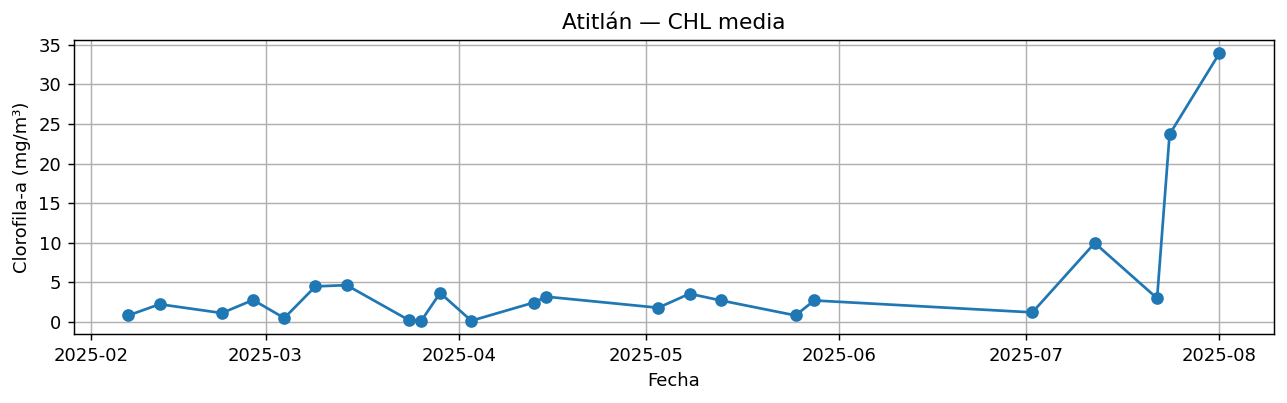

  ✔ Guardado: diagnosticos_corr\series_CHL_mean_Atitlán.png


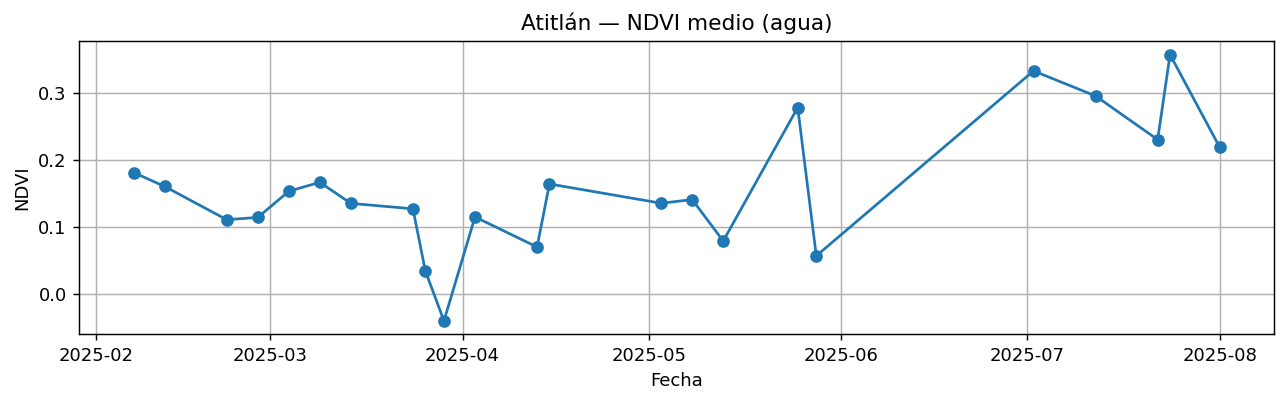

  ✔ Guardado: diagnosticos_corr\series_NDVI_mean_Atitlán.png


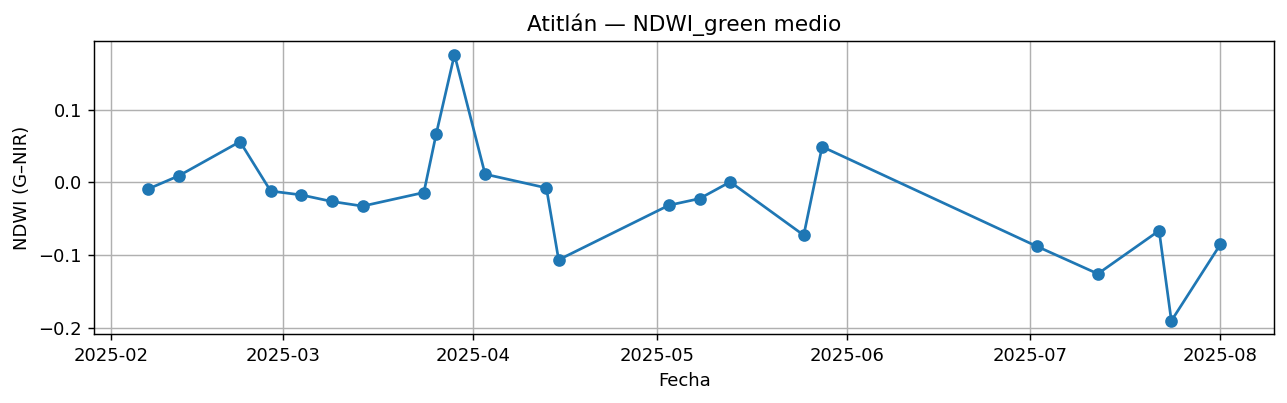

  ✔ Guardado: diagnosticos_corr\series_NDWIg_mean_Atitlán.png


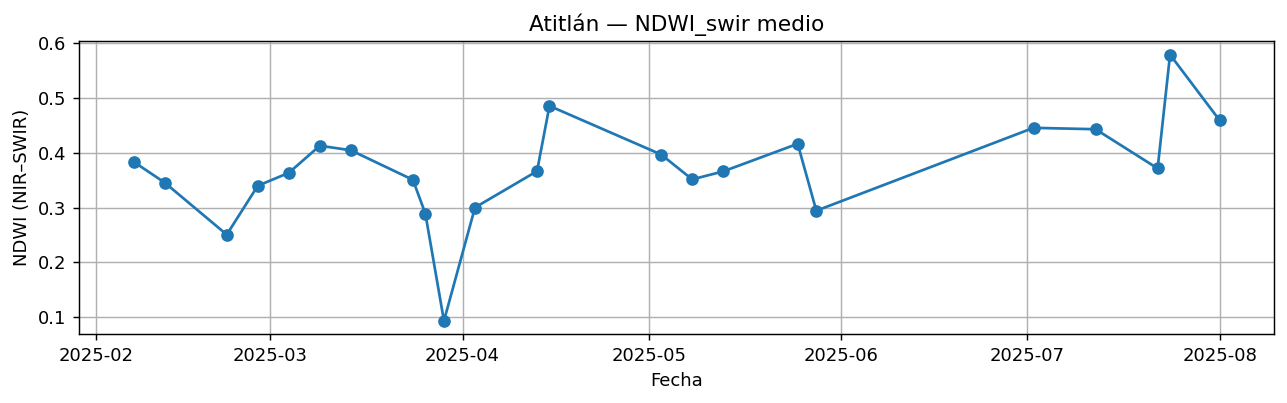

  ✔ Guardado: diagnosticos_corr\series_NDWIs_mean_Atitlán.png

=== Amatitlán ===


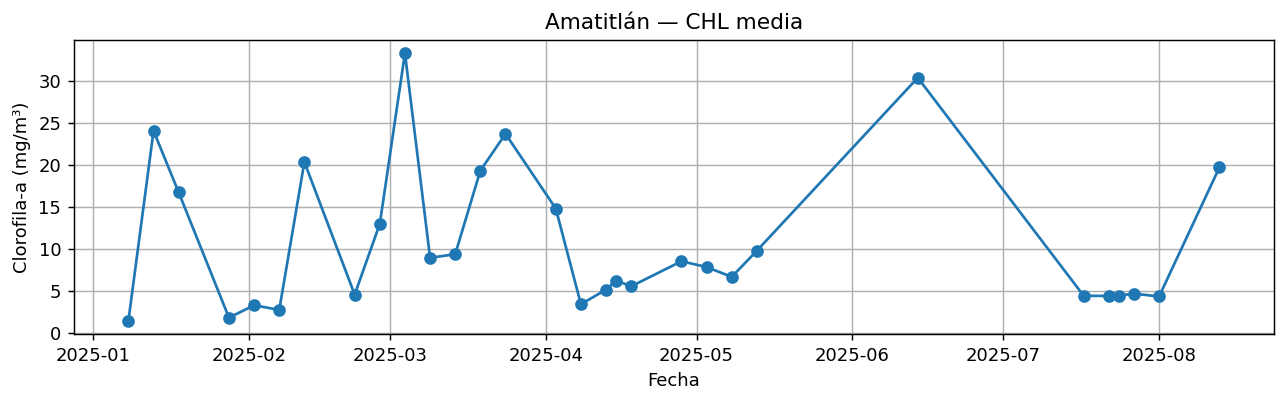

  ✔ Guardado: diagnosticos_corr\series_CHL_mean_Amatitlán.png


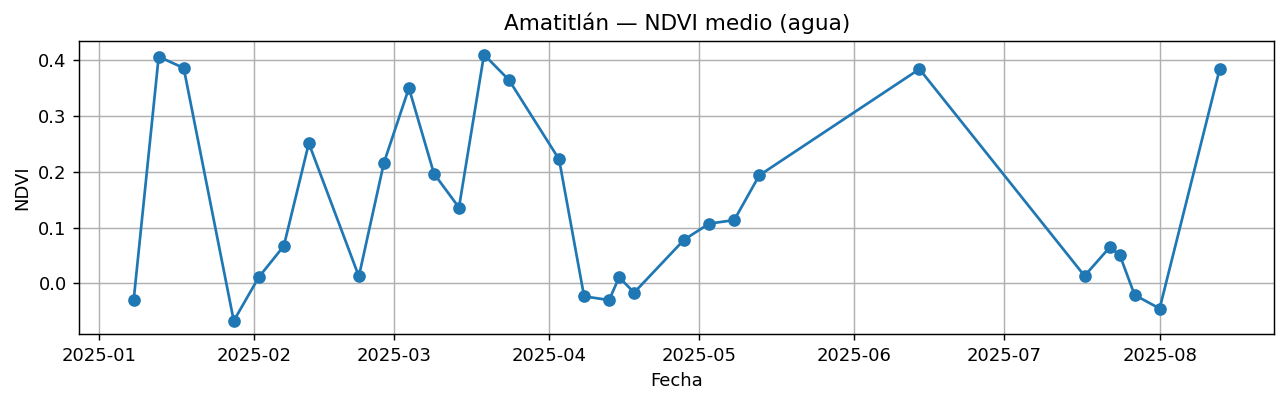

  ✔ Guardado: diagnosticos_corr\series_NDVI_mean_Amatitlán.png


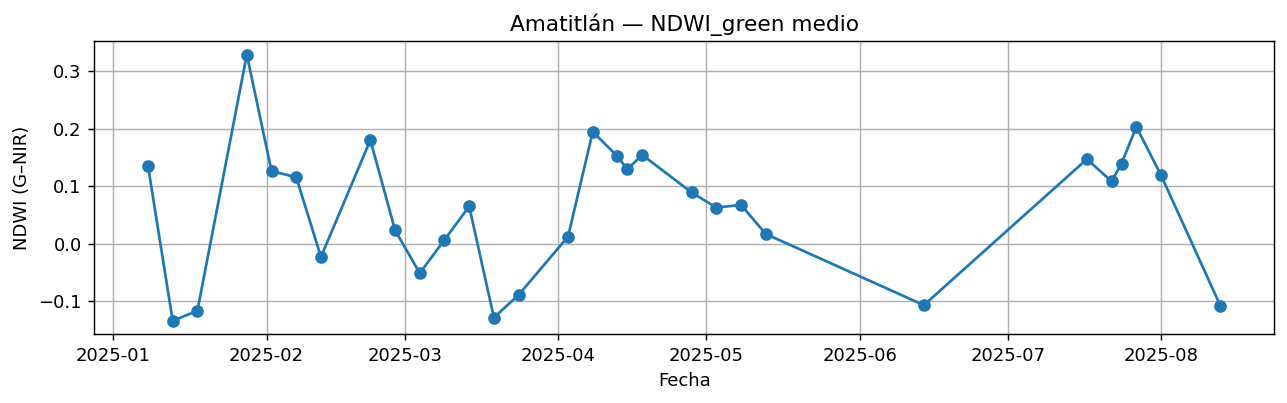

  ✔ Guardado: diagnosticos_corr\series_NDWIg_mean_Amatitlán.png


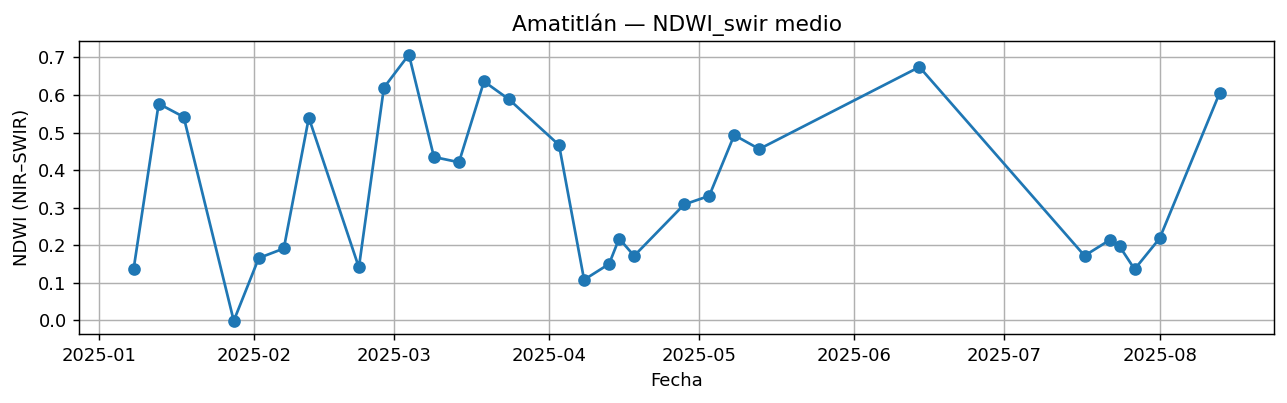

  ✔ Guardado: diagnosticos_corr\series_NDWIs_mean_Amatitlán.png

✅ Resumen guardado: diagnosticos_corr\resumen_corr_por_fecha.csv

📈 Medias de correlación (píxel-a-píxel) por lago:
  CHL vs NDVI  (Spearman):
lake
Amatitlán    0.387
Atitlán      0.293
Name: r_pix_ndvi_spearman, dtype: float64
  CHL vs NDWIg (Spearman):
lake
Amatitlán   -0.193
Atitlán     -0.218
Name: r_pix_ndwi_g_spearman, dtype: float64
  CHL vs NDWIs (Spearman):
lake
Amatitlán    0.289
Atitlán      0.097
Name: r_pix_ndwi_s_spearman, dtype: float64


In [ ]:

CYANO_OUT = "ciano_outputs"
LAKES = {
    # CHL (estricto/normal): donde están los *_chl.tif
    "Atitlán": {
        "chl_dirs": [os.path.join(CYANO_OUT, "descargas_atitlan_fechas")],
        # Candidatos donde podría estar el L2A multibanda (B02,B03,B04,B08,B11,...)
        "l2a_dirs": ["descargas_atitlan_fechas", "descargas_atitlan"]
    },
    "Amatitlán": {
        "chl_dirs": [os.path.join(CYANO_OUT, "descargas_amatitlan")],
        "l2a_dirs": ["descargas_amatitlan", "descargas_amatitlan_prueba", os.path.join(CYANO_OUT, "descargas_amatitlan")]
    },
}

OUT_DIR = "diagnosticos_corr"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

# -------------- Utils --------------
def list_chl_by_date(chl_dirs):
    """Devuelve lista [(date_iso, path_chl), ...] ordenada."""
    items = []
    for d in chl_dirs:
        paths = glob.glob(os.path.join(d, "**", "*_chl.tif"), recursive=True)
        for p in paths:
            m = DATE_RE.search(os.path.basename(p))
            if m:
                items.append((pd.to_datetime(m.group(1)).date().isoformat(), p))
    items.sort()
    # quitar duplicados por fecha, quedarnos con el primero
    seen, out = set(), []
    for dt, p in items:
        if dt not in seen:
            out.append((dt, p))
            seen.add(dt)
    return out

def find_l2a(date_iso, l2a_dirs):
    """
    Busca un tif L2A con bandas S2 para date_iso en múltiples carpetas.
    Acepta patrones flexibles, ignora *_chl* y *_cyano*.
    Devuelve path o None.
    """
    candidates = []
    for d in l2a_dirs:
        if not os.path.isdir(d):
            continue
        # patrones amplios
        patt = os.path.join(d, f"*{date_iso}*Z*.tif")
        for p in glob.glob(patt):
            b = os.path.basename(p).lower()
            if "_chl" in b or "cyano" in b:
                continue
            candidates.append(p)
        # también sin 'Z' explícita por si cambia el nombre
        patt2 = os.path.join(d, f"*{date_iso}*.tif")
        for p in glob.glob(patt2):
            b = os.path.basename(p).lower()
            if "_chl" in b or "cyano" in b:
                continue
            candidates.append(p)
    # filtrar por contenido (que tenga bandas útiles)
    for p in sorted(set(candidates)):
        try:
            with rasterio.open(p) as src:
                desc = [ (i+1, (src.descriptions[i] or "").upper()) for i in range(src.count) ]
                names = {name for _, name in desc}
                # mínimos requeridos para índices
                has_b03 = any("B03" in n for n in names)
                has_b04 = any("B04" in n for n in names)
                has_b08 = any("B08" in n for n in names)
                has_b11 = any("B11" in n for n in names)  # NDWI_swir
                if (has_b04 and has_b08 and has_b03) or (has_b04 and has_b08 and has_b11):
                    return p
        except Exception:
            pass
    return None

def band_index_by_name(src, key):
    """Devuelve índice (1-based) de banda cuyo nombre contiene key (e.g., 'B04')."""
    key = key.upper()
    for i in range(src.count):
        name = (src.descriptions[i] or "").upper()
        if key in name:
            return i + 1
    # Fallback heurístico para outputs típicos de openEO (orden conocido)
    order = ["B02","B03","B04","B05","B07","B8A","B08","B11","B12","SCL"]
    try:
        j = order.index(key)
        return j + 1 if src.count >= j+1 else None
    except ValueError:
        return None

def read_band(src, idx):
    a = src.read(idx).astype("float32")
    nd = src.nodata
    if nd is not None:
        a[a == nd] = np.nan
    return a

def compute_indices_from_l2a(l2a_path):
    """Devuelve dict con NDVI, NDWI_green, NDWI_swir y shape, transform."""
    with rasterio.open(l2a_path) as src:
        iB03 = band_index_by_name(src, "B03")
        iB04 = band_index_by_name(src, "B04")
        iB08 = band_index_by_name(src, "B08")
        iB11 = band_index_by_name(src, "B11")
        if not all([iB04, iB08]) or (not iB03 and not iB11):
            raise RuntimeError("L2A no tiene bandas necesarias (B03/B04/B08/B11).")

        B04 = read_band(src, iB04)   # red
        B08 = read_band(src, iB08)   # nir
        NDVI = (B08 - B04) / (B08 + B04)
        NDVI[np.isinf(NDVI)] = np.nan

        NDWI_g = None
        if iB03:
            B03 = read_band(src, iB03)   # green
            NDWI_g = (B03 - B08) / (B03 + B08)
            NDWI_g[np.isinf(NDWI_g)] = np.nan

        NDWI_s = None
        if iB11:
            B11 = read_band(src, iB11)   # swir
            NDWI_s = (B08 - B11) / (B08 + B11)
            NDWI_s[np.isinf(NDWI_s)] = np.nan

        return {
            "NDVI": NDVI,
            "NDWI_green": NDWI_g,
            "NDWI_swir": NDWI_s,
            "transform": src.transform,
            "crs": src.crs,
            "shape": (src.height, src.width),
        }

def load_chl(chl_path):
    with rasterio.open(chl_path) as src:
        a = src.read(1).astype("float32")
        nd = src.nodata
        if nd is not None:
            a[a == nd] = np.nan
        return a, src.transform, src.crs

def sample_pairs(a, b, max_n=300_000):
    """Devuelve vectores (x,y) con NaNs filtrados y muestreo aleatorio si supera max_n."""
    m = np.isfinite(a) & np.isfinite(b)
    x = a[m].ravel()
    y = b[m].ravel()
    if x.size > max_n:
        sel = np.random.default_rng(0).choice(x.size, size=max_n, replace=False)
        x, y = x[sel], y[sel]
    return x, y

def safe_corr(x, y):
    if x.size < 10:
        return np.nan, np.nan
    try:
        rP = pearsonr(x, y).statistic
    except Exception:
        rP = np.nan
    try:
        rS = spearmanr(x, y).correlation
    except Exception:
        rS = np.nan
    return float(rP), float(rS)

# -------------- Pipeline --------------
summary_rows = []

for lake, cfg in LAKES.items():
    print(f"\n=== {lake} ===")
    dates_chl = list_chl_by_date(cfg["chl_dirs"])
    if not dates_chl:
        print("  ⚠️ No se encontraron *_chl.tif.")
        continue

    # contenedores para series (medias por fecha)
    s_date, s_chl, s_ndvi, s_ndwi_g, s_ndwi_s = [], [], [], [], []

    for date_iso, chl_path in dates_chl:
        # CHL
        chl, _, _ = load_chl(chl_path)
        water_mask = np.isfinite(chl)

        # L2A
        l2a_path = find_l2a(date_iso, cfg["l2a_dirs"])
        if l2a_path is None:
            print(f"  ⚠️ {date_iso}: no hay L2A. Salto fecha.")
            continue

        idxs = compute_indices_from_l2a(l2a_path)

        # recortar índices a máscara de “agua válida” (basado en CHL)
        NDVI = idxs["NDVI"]; 
        NDVI = np.where(water_mask, NDVI, np.nan)

        if idxs["NDWI_green"] is not None:
            NDWI_g = np.where(water_mask, idxs["NDWI_green"], np.nan)
        else:
            NDWI_g = None

        if idxs["NDWI_swir"] is not None:
            NDWI_s = np.where(water_mask, idxs["NDWI_swir"], np.nan)
        else:
            NDWI_s = None

        # series (medias por fecha)
        s_date.append(pd.to_datetime(date_iso))
        s_chl.append(np.nanmean(chl))
        s_ndvi.append(np.nanmean(NDVI))
        s_ndwi_g.append(np.nanmean(NDWI_g) if NDWI_g is not None else np.nan)
        s_ndwi_s.append(np.nanmean(NDWI_s) if NDWI_s is not None else np.nan)

        # correlación píxel-a-píxel para la fecha
        # (se guarda fila por fecha para inspección)
        rP_ndvi, rS_ndvi = safe_corr(*sample_pairs(chl, NDVI))
        rP_g, rS_g = (np.nan, np.nan)
        if NDWI_g is not None:
            rP_g, rS_g = safe_corr(*sample_pairs(chl, NDWI_g))
        rP_s, rS_s = (np.nan, np.nan)
        if NDWI_s is not None:
            rP_s, rS_s = safe_corr(*sample_pairs(chl, NDWI_s))

        summary_rows.append({
            "lake": lake, "date": date_iso,
            "chl_mean": float(np.nanmean(chl)),
            "ndvi_mean": float(np.nanmean(NDVI)),
            "ndwi_g_mean": float(np.nanmean(NDWI_g)) if NDWI_g is not None else np.nan,
            "ndwi_s_mean": float(np.nanmean(NDWI_s)) if NDWI_s is not None else np.nan,
            "r_pix_ndvi_pearson": rP_ndvi, "r_pix_ndvi_spearman": rS_ndvi,
            "r_pix_ndwi_g_pearson": rP_g,  "r_pix_ndwi_g_spearman": rS_g,
            "r_pix_ndwi_s_pearson": rP_s,  "r_pix_ndwi_s_spearman": rS_s,
            "l2a_path": l2a_path, "chl_path": chl_path
        })

    # --- plots por lago (si hubo datos) ---
    if s_date:
        idx = pd.to_datetime(s_date)
        def lineplot(y, title, ylabel, fname):
            plt.figure(figsize=(10,3.2), dpi=130)
            plt.plot(idx, y, marker="o")
            plt.title(f"{lake} — {title}")
            plt.xlabel("Fecha"); plt.ylabel(ylabel); plt.grid(True); plt.tight_layout()
            out = os.path.join(OUT_DIR, f"{fname}_{lake}.png".replace(" ", "_"))
            plt.savefig(out); plt.show()
            print(f"  ✔ Guardado: {out}")

        lineplot(s_chl, "CHL media", "Clorofila-a (mg/m³)", "series_CHL_mean")
        lineplot(s_ndvi, "NDVI medio (agua)", "NDVI", "series_NDVI_mean")
        if not np.all(np.isnan(s_ndwi_g)):
            lineplot(s_ndwi_g, "NDWI_green medio", "NDWI (G–NIR)", "series_NDWIg_mean")
        if not np.all(np.isnan(s_ndwi_s)):
            lineplot(s_ndwi_s, "NDWI_swir medio", "NDWI (NIR–SWIR)", "series_NDWIs_mean")
    else:
        print(f"  ⚠️ {lake}: no hubo fechas con CHL+L2A para graficar.")

# --- resumen CSV ---
df = pd.DataFrame(summary_rows).sort_values(["lake","date"])
csv_path = os.path.join(OUT_DIR, "resumen_corr_por_fecha.csv")
df.to_csv(csv_path, index=False)
print(f"\n✅ Resumen guardado: {csv_path}")

# --- Resumen de correlaciones (medias por lago) ---
if not df.empty:
    def corr_by_lake(col):
        return df.groupby("lake")[col].mean(numeric_only=True)

    print("\n📈 Medias de correlación (píxel-a-píxel) por lago:")
    for pair in [
        ("r_pix_ndvi_spearman",  "CHL vs NDVI  (Spearman)"),
        ("r_pix_ndwi_g_spearman","CHL vs NDWIg (Spearman)"),
        ("r_pix_ndwi_s_spearman","CHL vs NDWIs (Spearman)")
    ]:
        col, label = pair
        print(f"  {label}:")
        print(corr_by_lake(col).round(3))


# Amatitlán — Resumen y correlaciones (Sentinel-2 L2A + CHL)

## 1) Señal temporal de clorofila-a (media del lago)
- **Picos principales de CHL** (mg/m³):
  - **2025-03-04:** **33.3**
  - **2025-06-14:** **30.4**
  - **2025-01-13:** **24.0**
  - **2025-03-24:** **23.7**
  - **2025-03-19:** **19.3**
- Entre picos, la CHL media suele oscilar en **4–10 mg/m³**.

## 2) Índices espectrales medios (sobre agua)
- **NDVI** positivo la mayor parte del tiempo (≈0.05–0.40), sube en los días con floraciones.
- **NDWI (G–NIR)** cerca de 0 o levemente positivo; **disminuye** con floraciones intensas.
- **NDWI (NIR–SWIR)** moderado–alto (≈0.1–0.7), **aumenta** durante floraciones.

## 3) Correlaciones pixel-a-pixel con CHL (por imagen)
_Patrón dominante en la mayoría de fechas (|r| ≳ 0.6 en >70% de las escenas):_
- **CHL vs NDVI:** **positiva** fuerte → más CHL ↔ mayor reflectancia NIR (firma “vegetación/escuma” de cianobacterias).
- **CHL vs NDWI (G–NIR):** **negativa** fuerte → la “acuosidad” basada en verde disminuye con floraciones.
- **CHL vs NDWI (NIR–SWIR):** **positiva** fuerte → el aumento de NIR por floraciones supera la contribución en SWIR ⇒ (NIR−SWIR)/(NIR+SWIR) crece.

**Ejemplos en días pico (Pearson; Spearman similar):**

| Fecha       | r(CHL, NDVI) | r(CHL, NDWI_g) | r(CHL, NDWI_s) |
|-------------|---------------|----------------|----------------|
| 2025-03-04  | **0.83**      | **−0.75**      | **0.72**       |
| 2025-06-14  | **0.77**      | **−0.71**      | **0.76**       |
| 2025-03-24  | **0.90**      | **−0.87**      | **0.74**       |
| 2025-03-19  | **0.84**      | **−0.81**      | **0.60**       |
| 2025-01-13  | **0.68**      | **−0.64**      | **0.63**       |

## 4) Interpretación rápida
- Las floraciones en Amatitlán muestran una **firma espectral coherente**: **NDVI↑**, **NDWI_g↓**, **NDWI_s↑** junto con **CHL↑**.
- Fechas con correlaciones débiles/invertidas (p.ej., **2025-01-08**, **2025-04-08**) probablemente están afectadas por **nubes finas, brillo especular o turbidez**, que distorsionan la relación local entre bandas.

## 5) Nota sobre umbrales indicativos (orientativos)
- Para **mapear probables floraciones** con Sentinel-2, una regla simple que funciona bien en Amatitlán es:
  - **NDVI > 0.2**, **NDWI_g < 0.1** y **NDWI_s > 0.3**  
  (ajustar a cada fecha según histogramas).


# Atitlán — Correlación CHL vs índices (resumen breve)

## Métricas globales (medias por fecha)
- **CHL vs NDVI** → **Pearson = 0.247**, **Spearman = −0.478**  
  _Señal débil e inestable; NDVI no es buen proxy en agua._
- **CHL vs NDWI_green** → **Pearson = 0.759**, **Spearman = 0.798**  
  _Relación positiva **fuerte y consistente**: cuando sube CHL, también NDWI_green._
- **CHL vs NDWI_swir** → **Pearson = −0.169**, **Spearman = −0.301**  
  _Tendencia negativa débil–moderada._

## Lo que muestran los dispersogramas (píxel-a-píxel)
- **NDVI vs CHL**: rₚ≈0.04, rₛ≈−0.24 → relación muy débil y ruidosa.  
- **NDWI_green vs CHL**: rₚ≈0.05, rₛ≈0.39 → señal positiva **moderada** a nivel de píxel.  
- **NDWI_swir vs CHL**: rₚ≈0.01, rₛ≈0.00 → sin relación clara.  
- Se observan outliers (índices fuera de ±1 y CHL saturado a 200), que aplanan las nubes de puntos.

## Lectura del CSV (fecha a fecha)
- **Cobertura válida** ≈ 100% en todas las fechas (min 99.58% el 2025-02-07).
- **Picos de presencia** (CHL≥10 mg/m³):  
  2025-02-07 **33%**, 2025-05-25 **8.8%**, 2025-04-03 **7.8%**, 2025-07-24 **7.0%**.
- **Coherencia con índices (píxel-a-píxel, Spearman por fecha):**
  - `r_pix_ndwi_g_spearman` es **mayormente positivo** (p.ej. 0.49 el 2025-05-08; 0.45 el 2025-05-25; 0.43 el 2025-04-03).  
    _Refuerza la utilidad de **NDWI_green** para co-variar con CHL._
  - `r_pix_ndvi_spearman` es **negativo** en la mayoría de fechas (−0.52, −0.43, −0.40, …), con alguna excepción (0.44 el 2025-02-07).  
    _NDVI es poco fiable en agua._
  - `r_pix_ndwi_s_spearman` ~0 o negativo débil → sin patrón consistente.
- **Correlación presencia–índices (r_pres_*)**: magnitudes pequeñas (|r|≲0.24).  
  _Los índices por sí solos discriminan débilmente el umbral de presencia a nivel de píxel._

## Conclusión práctica
- **NDWI_green** es el **mejor indicador auxiliar** para la dinámica de CHL en Atitlán (fuerte por fecha, moderado por píxel).  
- **NDVI** y **NDWI_swir** muestran poca utilidad operativa para cianobacteria en este conjunto.


## **Inciso 9**

In [33]:
# ================================================================
# 9) Proliferación y comparación entre lagos (Atitlán + Amatitlán)
#    Lee tus *_chl*.tif, calcula métricas, detecta picos y compara
#    Guarda CSVs y gráficos en ./comparativos
# ================================================================

import os, re, glob, math
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

OUTDIR = "comparativos"
os.makedirs(OUTDIR, exist_ok=True)

LAKES = {
    "Atitlán": [
        "chl_soft_out",
        os.path.join("ciano_outputs", "descargas_atitlan_fechas"),
        os.path.join("ciano_outputs", "descargas_atitlan"),
    ],
    "Amatitlán": [
        os.path.join("ciano_outputs", "descargas_amatitlan"),
    ],
}

THR_LOW  = 10.0   # mg/m³
THR_HIGH = 20.0   # mg/m³
CLIP_MAX = 200.0
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

def find_chl_paths(candidates):
    for root in candidates:
        if not os.path.isdir(root):
            continue
        paths = sorted(glob.glob(os.path.join(root, "**", "*_chl*.tif"), recursive=True))
        paths = [p for p in paths if "cyano_rgb" not in os.path.basename(p).lower()]
        if paths:
            items = []
            for p in paths:
                m = DATE_RE.search(p)
                if m:
                    items.append((pd.to_datetime(m.group(1)).date(), p))
            if items:
                items = sorted(items, key=lambda t: t[0])
                dates = [d.isoformat() for d,_ in items]
                paths = [p for _,p in items]
                return dates, paths, root
    return [], [], None

def read_chl(path):
    with rasterio.open(path) as src:
        a = src.read(1).astype(np.float32)
        if src.nodata is not None:
            a[a == src.nodata] = np.nan
        a = np.clip(a, 0, CLIP_MAX)
        transform = src.transform
        crs = src.crs
    return a, transform, crs

def pixel_area_m2(transform, crs):
    if crs and hasattr(crs, "to_string") and "EPSG:4326" not in crs.to_string():
        sx = abs(transform.a)
        sy = abs(transform.e)
        return float(sx * sy)
    return None

def per_date_metrics(path):
    a, tr, crs = read_chl(path)
    pix_area = pixel_area_m2(tr, crs)

    valid = np.isfinite(a)
    lake_px = int(valid.size)
    valid_px = int(valid.sum())
    if valid_px == 0:
        return dict(lake_px=lake_px, valid_px=0, coverage_pct=0.0)

    vals = a[valid]
    mean   = float(np.nanmean(vals))
    median = float(np.nanmedian(vals))
    p90    = float(np.nanpercentile(vals, 90))
    p99    = float(np.nanpercentile(vals, 99))
    vmax   = float(np.nanmax(vals))

    pres_low  = float((vals >= THR_LOW ).sum())  / valid_px * 100.0
    pres_high = float((vals >= THR_HIGH).sum()) / valid_px * 100.0

    area_day_low  = None
    area_day_high = None
    if pix_area is not None:
        area_day_low  = ((vals >= THR_LOW ).sum() * pix_area) / 1e6
        area_day_high = ((vals >= THR_HIGH).sum() * pix_area) / 1e6

    return dict(
        lake_px=lake_px, valid_px=valid_px, coverage_pct=valid_px*100.0/lake_px,
        chl_mean=mean, chl_median=median, chl_p90=p90, chl_p99=p99, chl_max=vmax,
        presence_low_pct=pres_low, presence_high_pct=pres_high,
        area_day_low=area_day_low, area_day_high=area_day_high
    )

def robust_peaks(dates, y, win=5, k_mad=2.0, min_height=None, distance=2):
    s = pd.Series(y, index=pd.to_datetime(dates))
    base = s.rolling(win, center=True, min_periods=1).median()
    resid = s - base
    mad = np.median(np.abs(resid.values - np.median(resid.values)))
    thr = max(k_mad * mad, 1e-6)
    cand = resid.values > thr
    if min_height is not None:
        cand |= (s.values >= min_height)
    idx = np.where(cand)[0]
    if idx.size == 0:
        return np.array([], dtype=int), base.values
    keep, j = [], 0
    while j < len(idx):
        group = [idx[j]]
        k = j + 1
        while k < len(idx) and (idx[k] - group[-1]) <= distance:
            group.append(idx[k]); k += 1
        g = group[np.argmax(s.values[group])]
        keep.append(g)
        j = k
    return np.array(keep, dtype=int), base.values

all_summaries = []
per_lake_df   = {}

for lake, folders in LAKES.items():
    dates, paths, used_root = find_chl_paths(folders)
    if not paths:
        print(f"⚠️ {lake}: no encontré *_chl*.tif en {folders}")
        continue

    print(f"\n=== {lake} ===  ({len(paths)} escenas)  origen: {used_root}")
    rows = []
    for d, p in zip(dates, paths):
        m = per_date_metrics(p)
        m.update({"date": d, "lake": lake, "path": p})
        rows.append(m)

    # --- CORRECCIÓN: usar la columna 'date' como índice y eliminar duplicados ---
    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date", drop=True)      # ahora 'date' solo está en el índice
    df.index.name = "date"
    df.sort_index(inplace=True)

    per_lake_df[lake] = df

    # Guardar CSV por lago (ya no hay colisión al resetear)
    out_csv = os.path.join(OUTDIR, f"resumen_{lake}.csv".replace(" ", "_"))
    df.reset_index().to_csv(out_csv, index=False)
    print(f"  ✔ CSV: {out_csv}")

    # Detectar picos y graficar
    y = df["chl_mean"].values
    pk, base = robust_peaks(df.index.astype(str).tolist(), y, win=5, k_mad=2.0, min_height=None, distance=2)

    plt.figure(figsize=(11,3.6), dpi=140)
    plt.plot(df.index, y, label="CHL media", lw=2)
    if "chl_p90" in df:
        plt.plot(df.index, df["chl_p90"].values, "--", label="P90", lw=1)
    plt.plot(df.index, base, ":", label="baseline (mediana win=5)", lw=1)
    if pk.size:
        plt.scatter(df.index[pk], y[pk], s=35, zorder=3, label="picos")
    plt.grid(True, alpha=.3); plt.legend(); plt.title(f"{lake} — CHL (media y P90)")
    plt.ylabel("mg/m³")
    out_plot = os.path.join(OUTDIR, f"{lake}_timeseries.png".replace(" ", "_"))
    plt.tight_layout(); plt.savefig(out_plot); plt.close()
    print(f"  ✔ Plot: {out_plot}")

    plt.figure(figsize=(11,3.6), dpi=140)
    plt.plot(df.index, df["presence_low_pct"],  "-o", ms=4, label=f"≥{THR_LOW:g} mg/m³")
    plt.plot(df.index, df["presence_high_pct"], "-o", ms=4, label=f"≥{THR_HIGH:g} mg/m³")
    plt.grid(True, alpha=.3); plt.legend(); plt.title(f"{lake} — % superficie con CHL ≥ umbral")
    plt.ylabel("% del lago")
    out_plot = os.path.join(OUTDIR, f"{lake}_presencia.png".replace(" ", "_"))
    plt.tight_layout(); plt.savefig(out_plot); plt.close()
    print(f"  ✔ Plot: {out_plot}")

    freq_low  = int((df["presence_low_pct"]  > 0.5).sum())
    freq_high = int((df["presence_high_pct"] > 0.5).sum())
    intensity_low  = float(np.nansum(df["area_day_low" ].values))  if "area_day_low"  in df else np.nan
    intensity_high = float(np.nansum(df["area_day_high"].values)) if "area_day_high" in df else np.nan

    all_summaries.append({
        "lake": lake,
        "n_dates": len(df),
        "mean_CHL": float(df["chl_mean"].mean()),
        "p90_CHL":  float(df["chl_p90"].mean()) if "chl_p90" in df else np.nan,
        "max_CHL":  float(df["chl_max"].max())  if "chl_max" in df else np.nan,
        "freq_days_pres_low(>=10mg/m3)":  freq_low,
        "freq_days_pres_high(>=20mg/m3)": freq_high,
        "area_days_low_km2":  intensity_low,
        "area_days_high_km2": intensity_high,
    })

# -------------------- Comparación entre lagos -------------------
if len(per_lake_df) >= 2:
    comp = pd.DataFrame(all_summaries)
    comp_out = os.path.join(OUTDIR, "comparativo_resumen.csv")
    comp.to_csv(comp_out, index=False)
    print(f"\n✔ Comparativo CSV: {comp_out}\n")
    print(comp)

    plt.figure(figsize=(11,3.8), dpi=140)
    for lake, df in per_lake_df.items():
        plt.plot(df.index, df["chl_mean"], "-o", ms=3, label=lake)
    plt.grid(True, alpha=.3); plt.legend(); plt.title("CHL media — comparación de lagos"); plt.ylabel("mg/m³")
    out = os.path.join(OUTDIR, "comparativo_timeseries_chl_mean.png")
    plt.tight_layout(); plt.savefig(out); plt.close()
    print(f"✔ Plot: {out}")

    plt.figure(figsize=(7,4), dpi=140)
    data = [df["chl_mean"].values for _, df in per_lake_df.items()]
    labels = list(per_lake_df.keys())
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.ylabel("CHL media (mg/m³)"); plt.title("Distribución de CHL media por lago")
    out = os.path.join(OUTDIR, "comparativo_boxplot_chl_mean.png")
    plt.tight_layout(); plt.savefig(out); plt.close()
    print(f"✔ Plot: {out}")

    plt.figure(figsize=(8,4), dpi=140)
    x = np.arange(len(comp)); w = 0.35
    plt.bar(x - w/2, comp["freq_days_pres_low(>=10mg/m3)"],  width=w, label=f"≥{THR_LOW:g}")
    plt.bar(x + w/2, comp["freq_days_pres_high(>=20mg/m3)"], width=w, label=f"≥{THR_HIGH:g}")
    plt.xticks(x, comp["lake"]); plt.ylabel("nº de días"); plt.title("Frecuencia de presencia por lago")
    plt.legend(); plt.grid(True, axis="y", alpha=.3)
    out = os.path.join(OUTDIR, "comparativo_frecuencias.png")
    plt.tight_layout(); plt.savefig(out); plt.close()
    print(f"✔ Plot: {out}")

    if comp["area_days_low_km2"].notna().any():
        plt.figure(figsize=(8,4), dpi=140)
        plt.bar(comp["lake"], comp["area_days_low_km2"], label=f"≥{THR_LOW:g}")
        plt.bar(comp["lake"], comp["area_days_high_km2"], alpha=.6, label=f"≥{THR_HIGH:g}")
        plt.ylabel("km²·día"); plt.title("Intensidad (área-días) por lago")
        plt.legend(); plt.grid(True, axis="y", alpha=.3)
        out = os.path.join(OUTDIR, "comparativo_intensidad_areadays.png")
        plt.tight_layout(); plt.savefig(out); plt.close()
        print(f"✔ Plot: {out}")

else:
    print("\nℹ️ Solo se encontró un lago; se omiten las gráficas comparativas.")



=== Atitlán ===  (23 escenas)  origen: chl_soft_out
  ✔ CSV: comparativos\resumen_Atitlán.csv
  ✔ Plot: comparativos\Atitlán_timeseries.png
  ✔ Plot: comparativos\Atitlán_presencia.png

=== Amatitlán ===  (30 escenas)  origen: ciano_outputs\descargas_amatitlan
  ✔ CSV: comparativos\resumen_Amatitlán.csv
  ✔ Plot: comparativos\Amatitlán_timeseries.png
  ✔ Plot: comparativos\Amatitlán_presencia.png

✔ Comparativo CSV: comparativos\comparativo_resumen.csv

        lake  n_dates   mean_CHL    p90_CHL     max_CHL  \
0    Atitlán       23   5.575184   7.956929  200.000000   
1  Amatitlán       30  10.734887  17.607328   90.873665   

   freq_days_pres_low(>=10mg/m3)  freq_days_pres_high(>=20mg/m3)  \
0                             20                               4   
1                             22                              17   

   area_days_low_km2  area_days_high_km2  
0            96.6614             24.3669  
1            12.8884              6.5747  
✔ Plot: comparativos\comparat

C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\2433644161.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


✔ Plot: comparativos\comparativo_frecuencias.png
✔ Plot: comparativos\comparativo_intensidad_areadays.png


# Comparativo de floraciones — Atitlán vs Amatitlán (feb–ago 2025)

> Basado en los gráficos de series de tiempo, presencia por umbral, boxplots y comparación de medias.

---

## 9.1. Evolución por lago

### Atitlán
- **Nivel basal**: estable y bajo, con **media ~5–6 mg/m³** (mediana ≈ 5–6 en el boxplot).
- **Picos**: un evento destacado el **2025-02-07** (**CHL≈14 mg/m³; P90≈25**). El resto del periodo se mantiene moderado (P90 ~6–9).
- **Extensión espacial (umbral)**:
  - **≥10 mg/m³**: casi siempre **<5%** del lago; máximos ~**8–9%** (finales de mayo) y **33%** el 2025-02-07.
  - **≥20 mg/m³**: **casi nulo**; sólo trazas puntuales.

**Lectura**: régimen predominantemente meso-/oligotrófico con un evento temprano intenso pero breve y cobertura reducida el resto del periodo.

---

### Amatitlán
- **Nivel basal**: mayor variabilidad y niveles altos; **mediana ~7 mg/m³** con **valores frecuentes >15–20 mg/m³**.
- **Picos**: varios episodios fuertes (ene–abr) y uno mayor en **junio** (**medias ~30 mg/m³; P90 >45–50**).
- **Extensión espacial (umbral)**:
  - **≥10 mg/m³**: coberturas **muy altas** en varios días (**>90%** a inicios de marzo y mediados de junio).
  - **≥20 mg/m³**: episodios extensos (**~85%** a mediados de junio).

**Lectura**: régimen **claramente eutrófico**, con floraciones extensas y repetidas, especialmente en temporada seca y a inicios de lluvias.

---

## 9.2. Intensidad y frecuencia de floraciones

| Indicador (feb–ago 2025) | Atitlán | Amatitlán |
|---|---:|---:|
| Días con **≥10 mg/m³** en ≥1% del lago | **20** | **22** |
| Días con **≥20 mg/m³** en ≥1% del lago | **4** | **17** |
| Nivel típico (mediana CHL media) | **~5–6 mg/m³** | **~7 mg/m³** (con colas largas >30) |
| Picos de P90 | **~25 mg/m³** (caso aislado) | **>50 mg/m³** (varios episodios) |
| Cobertura máxima ≥20 mg/m³ | **≈2–3%** | **≈85%** |

**Conclusión comparativa**
- **Frecuencia**: similar conteo de días con presencia ≥10 mg/m³, pero Amatitlán acumula **muchos más días** con niveles **≥20 mg/m³**.
- **Intensidad**: Amatitlán muestra **picos más altos** y **coberturas masivas**; Atitlán se mantiene **moderado** salvo un evento puntual.

---

## 9.3. Posibles diferencias en causas (interpretación cualitativa)
- **Morfometría y tamaño**: lagos más **pequeños y someros** (como Amatitlán) calientan y se mezclan distinto, favoreciendo floraciones extensas; Atitlán, **más grande y profundo**, amortigua picos y los concentra localmente.
- **Aporte de nutrientes**: la **presión urbana/industrial y agrícola** habitualmente eleva N y P en cuencas más urbanizadas (compatibles con los patrones de Amatitlán). Atitlán suele reportarse con **menor carga** relativa.
- **Estacionalidad**: la **temporada seca** y el **inicio de lluvias** alinean varios picos en Amatitlán (temperatura del agua alta + estabilidad de columna; luego pulsos de escorrentía). En Atitlán los eventos son **más breves** y con **menor cobertura**.

> Estas interpretaciones son consistentes con las series y mapas del periodo, pero la atribución causal fuerte requeriría medir nutrientes (TN/TP), temperatura del agua, vientos/estratificación y usos de suelo por subcuencas.

---
**Resumen ejecutivo**
- **Atitlán**: niveles **bajos-moderados**, **un pico** temprano y **cobertura limitada** el resto del periodo.  
- **Amatitlán**: **floraciones intensas y frecuentes**, con **coberturas masivas** (≥20 mg/m³ hasta 85%) y **picos** de P90 >50 mg/m³.
